In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

class AdaptivePrivacyPatchDrop(layers.Layer):
    """
    Novel Privacy-Aware Patch Dropout Layer
    - Drops or attenuates patches based on learned sensitivity
    - Can improve privacy by removing identity-revealing patches
    """
    def __init__(self, base_drop_rate=0.1, sensitivity_strength=0.5, **kwargs):
        super().__init__(**kwargs)
        self.base_drop_rate = base_drop_rate          # Minimum drop rate
        self.sensitivity_strength = sensitivity_strength  # How strongly to drop sensitive patches
        self.last_mask = None

    def build(self, input_shape):
        # Learnable sensitivity per embedding dimension
        # shape: (embedding_dim,)
        self.sensitivity_weights = self.add_weight(
            shape=(input_shape[-1],),
            initializer="ones",
            trainable=True,
            name="sensitivity_weights"
        )
        super().build(input_shape)

    def call(self, patches, training=None):
        if not training or self.base_drop_rate <= 0.0:
            return patches

        # Compute patch sensitivity: L2 norm weighted by sensitivity_weights
        # shape: (batch_size, num_patches)
        patch_sensitivity = tf.norm(patches * self.sensitivity_weights, axis=-1)

        # Normalize to [0, 1] to get probability
        patch_sensitivity = patch_sensitivity / (tf.reduce_max(patch_sensitivity, axis=-1, keepdims=True) + 1e-6)

        # Compute adaptive drop probability per patch
        drop_prob = self.base_drop_rate + self.sensitivity_strength * patch_sensitivity
        drop_prob = tf.clip_by_value(drop_prob, 0.0, 0.95)  # avoid dropping all patches

        # Create random mask
        random_tensor = tf.random.uniform(tf.shape(drop_prob))
        mask = tf.cast(random_tensor >= drop_prob, patches.dtype)
        mask = tf.expand_dims(mask, axis=-1)  # broadcast over embedding dim
        self.last_mask = mask  # Store last mask for inspection if needed

        # Apply mask
        return patches * mask

    # def call(self, patches, training=None):
    #     if not training or self.base_drop_rate <= 0.0:
    #         return patches

    #     patch_sensitivity = tf.norm(patches * self.sensitivity_weights, axis=-1)  # (batch, num_patches)

    #     num_patches = tf.shape(patch_sensitivity)[1]
    #     k = tf.cast(tf.round(self.base_drop_rate * tf.cast(num_patches, tf.float32)), tf.int32)

    #     def drop_top_k_per_sample(sens):
    #         # sens: (197,)
    #         top_k = tf.math.top_k(sens, k=k).indices
    #         mask = tf.ones_like(sens)
    #         mask = tf.tensor_scatter_nd_update(
    #             mask,
    #             tf.expand_dims(top_k, axis=-1),
    #             tf.zeros_like(top_k, dtype=mask.dtype)
    #         )
    #         return mask

    #     mask = tf.map_fn(drop_top_k_per_sample, patch_sensitivity, dtype=patch_sensitivity.dtype)
    #     mask = tf.expand_dims(mask, axis=-1)  # (batch, num_patches, 1)
    #     self.last_mask = mask

    #     return patches * mask

class PatchExtract(layers.Layer):
    """Extract patches from input images with improved efficiency"""
    def __init__(self, patch_size):
        super(PatchExtract, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEmbedding(layers.Layer):
    """Enhanced patch embedding with learnable class token"""
    def __init__(self, num_patches, projection_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
        # Add learnable class token for better global representation
        self.class_token = self.add_weight(
            shape=(1, 1, projection_dim),
            initializer="random_normal",
            trainable=True,
            name="class_token"
        )

    def call(self, patch):
        batch_size = tf.shape(patch)[0]
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        
        # Add class token to each batch
        class_tokens = tf.broadcast_to(self.class_token, [batch_size, 1, self.class_token.shape[-1]])
        
        # Project patches and add positional encoding
        encoded = self.projection(patch) + self.position_embedding(positions)
        
        # Concatenate class token
        encoded = tf.concat([class_tokens, encoded], axis=1)
        return encoded

class MultiHeadAttention(layers.Layer):
    """Improved multi-head attention with better initialization"""
    def __init__(self, embed_dim, num_heads=8, dropout_rate=0.1):
        super(MultiHeadAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        
        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embedding dimension = {embed_dim} should be divisible by number of heads = {num_heads}"
            )
        
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim, kernel_initializer="glorot_uniform")
        self.key_dense = layers.Dense(embed_dim, kernel_initializer="glorot_uniform")
        self.value_dense = layers.Dense(embed_dim, kernel_initializer="glorot_uniform")
        self.combine_heads = layers.Dense(embed_dim, kernel_initializer="glorot_uniform")
        self.dropout = layers.Dropout(dropout_rate)

    def attention(self, query, key, value, training=None):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        weights = self.dropout(weights, training=training)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        
        attention, weights = self.attention(query, key, value, training=training)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output

class TransformerBlock(layers.Layer):
    """Enhanced transformer block with improved regularization"""
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(embed_dim, num_heads, rate)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),  # GELU often works better than ReLU
            layers.Dropout(rate),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        # Pre-norm architecture (often more stable)
        norm1 = self.layernorm1(inputs)
        attn_output = self.att(norm1, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = inputs + attn_output
        
        norm2 = self.layernorm2(out1)
        ffn_output = self.ffn(norm2, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return out1 + ffn_output

class UpsampleBlock(layers.Layer):
    """Enhanced upsampling block with skip connections support"""
    def __init__(self, filters, kernel_size=3, use_attention=False):
        super(UpsampleBlock, self).__init__()
        self.filters = filters
        self.use_attention = use_attention
        
        # Main upsampling path
        self.upsample = layers.Conv2DTranspose(
            filters, 2, strides=2, padding='same',
            kernel_initializer='he_normal'
        )
        self.conv1 = layers.Conv2D(
            filters, kernel_size, padding='same',
            kernel_initializer='he_normal'
        )
        self.conv2 = layers.Conv2D(
            filters, kernel_size, padding='same',
            kernel_initializer='he_normal'
        )
        
        # Normalization and activation
        self.bn1 = layers.BatchNormalization()
        self.bn2 = layers.BatchNormalization()
        self.activation = layers.Activation('gelu')
        
        # Optional spatial attention
        if use_attention:
            self.spatial_attention = layers.Conv2D(1, 7, padding='same', activation='sigmoid')
        
    def call(self, x, training=None):
        x = self.upsample(x)
        x = self.conv1(x)
        x = self.bn1(x, training=training)
        x = self.activation(x)
        
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        x = self.activation(x)
        
        # Apply spatial attention if enabled
        if self.use_attention:
            attention_weights = self.spatial_attention(x)
            x = x * attention_weights
            
        return x

class PrivacyAwareFeatureExtractor(layers.Layer):
    """
    Privacy-Aware Feature Extractor (First component in peer review architecture)
    Extracts features while removing identity-specific information
    """
    def __init__(self, projection_dim, anonymization_strength=0.3, name="privacy_aware_feature_extractor"):
        super(PrivacyAwareFeatureExtractor, self).__init__(name=name)
        self.projection_dim = projection_dim
        self.anonymization_strength = anonymization_strength
        
        # Privacy-aware feature projection
        self.privacy_projection = layers.Dense(
            projection_dim, 
            activation='gelu',
            kernel_initializer='he_normal',
            name='privacy_projection'
        )
        
        # Identity suppression layer
        self.identity_suppression = layers.Dense(
            projection_dim,
            use_bias=False,
            kernel_initializer='orthogonal',
            name='identity_suppression'
        )
        
        # Feature normalization
        self.feature_norm = layers.LayerNormalization(epsilon=1e-6, name='privacy_norm')
        
    def call(self, x, training=None):
        # Initial feature projection
        features = self.privacy_projection(x)
        
        if training:
            # Apply identity suppression during training
            suppressed = self.identity_suppression(features)
            # Blend original and suppressed features
            features = (1 - self.anonymization_strength) * features + self.anonymization_strength * suppressed
        
        # Normalize features
        features = self.feature_norm(features)
        return features

class DifferentialPrivacyLayer(layers.Layer):
    """
    Differential Privacy Layer (Third component in peer review architecture)
    Adds calibrated noise for formal privacy guarantees
    """
    def __init__(self, noise_scale=0.1, clip_norm=1.0, name="differential_privacy_layer"):
        super(DifferentialPrivacyLayer, self).__init__(name=name)
        self.noise_scale = noise_scale
        self.clip_norm = clip_norm
        
    def call(self, x, training=None):
        if not training:
            return x
        
        # Gradient clipping for DP
        if self.clip_norm > 0:
            x = tf.clip_by_norm(x, self.clip_norm, axes=-1)
        
        # Add calibrated Gaussian noise
        noise = tf.random.normal(
            tf.shape(x), 
            mean=0.0, 
            stddev=self.noise_scale,
            dtype=x.dtype
        )
        
        return x + noise
    

def create_enhanced_vit_eye_segmentation_model(
    image_size=224,
    patch_size=16,
    num_patches=196,
    projection_dim=768,
    num_heads=12,
    transformer_units=[3072, 768],
    transformer_layers=8,
    num_classes=4,
    dropout_rate=0.1,
    input_channels=1,
    use_attention_in_decoder=True,
    # Privacy parameters
    base_drop_rate=0.1,
    sensitivity_strength=0.5,
    dp_clip_norm=1.0,
    anonymization_strength=0.3,
    differential_privacy_noise=0.05
):
    
    inputs = layers.Input(shape=(image_size, image_size, input_channels))
    
    # Create patches
    patches = PatchExtract(patch_size)(inputs)
    
    # Encode patches (now includes class token)
    encoded_patches = PatchEmbedding(num_patches, projection_dim)(patches)

    encoded_patches = AdaptivePrivacyPatchDrop(
        base_drop_rate=base_drop_rate, 
        sensitivity_strength= sensitivity_strength)(encoded_patches, training=True)
    

    if(anonymization_strength > 0.0):
        encoded_patches = PrivacyAwareFeatureExtractor(
        projection_dim=projection_dim,
        anonymization_strength=anonymization_strength,
        name="privacy_aware_feature_extractor"
        )(encoded_patches)
    
    

    for _ in range(transformer_layers):
        encoded_patches = TransformerBlock(
            projection_dim, num_heads, transformer_units[0], dropout_rate
        )(encoded_patches)
    
    # Layer normalization
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

    privacy_protected_features = DifferentialPrivacyLayer(
        noise_scale=differential_privacy_noise,
        clip_norm=dp_clip_norm,
        name="differential_privacy_layer"
    )(representation)

    representation = privacy_protected_features[:, 1:, :] 
    
    # Reshape for decoder
    h = w = int(np.sqrt(num_patches))
    representation = layers.Reshape((h, w, projection_dim))(representation)
    
    # Enhanced decoder with optional attention
    x = UpsampleBlock(512, use_attention=use_attention_in_decoder)(representation)  # 14x14 -> 28x28
    x = UpsampleBlock(256, use_attention=use_attention_in_decoder)(x)               # 28x28 -> 56x56
    x = UpsampleBlock(128, use_attention=use_attention_in_decoder)(x)               # 56x56 -> 112x112
    x = UpsampleBlock(64, use_attention=use_attention_in_decoder)(x)                # 112x112 -> 224x224
    
    # Final segmentation layer with improved initialization
    segmentation_output = layers.Conv2D(
        num_classes, 1, 
        activation='softmax', 
        name='segmentation',
        kernel_initializer='he_normal'
    )(x)
    
    model = keras.Model(inputs, segmentation_output, name="Enhanced_ViT_Eye_Segmentation")
    return model


# Enhanced loss functions
def dice_coefficient_enhanced(y_true, y_pred, smooth=1e-6, class_weights=None):
    """Enhanced dice coefficient with class weighting"""
    # Convert sparse labels to one-hot
    if len(y_true.shape) != len(y_pred.shape):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
        y_true = tf.cast(y_true, tf.float32)
    
    # Flatten tensors
    y_true_f = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
    y_pred_f = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
    
    # Calculate intersection and union for each class
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    union = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0)
    dice_per_class = (2. * intersection + smooth) / (union + smooth)
    
    # Apply class weights if provided
    if class_weights is not None:
        class_weights = tf.constant(class_weights, dtype=tf.float32)
        dice_per_class = dice_per_class * class_weights
    
    return tf.reduce_mean(dice_per_class)

# Enhanced data loading with better augmentation
def enhanced_data_augmentation():
    """Create enhanced data augmentation pipeline"""
    def augment_data(image, label):
        # Random horizontal flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)
            label = tf.image.flip_left_right(tf.expand_dims(label, -1))
            label = tf.squeeze(label, -1)
        
        # Random rotation (small angles)
        if tf.random.uniform(()) > 0.7:
            angle = tf.random.uniform((), -0.1, 0.1)  # ±5.7 degrees
            image = tf.image.rot90(image, k=tf.cast(angle * 4, tf.int32))
            label = tf.image.rot90(tf.expand_dims(label, -1), k=tf.cast(angle * 4, tf.int32))
            label = tf.squeeze(label, -1)
        
        # Random brightness and contrast
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_brightness(image, 0.15)
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_contrast(image, 0.85, 1.15)
        
        # Random noise
        if tf.random.uniform(()) > 0.8:
            noise = tf.random.normal(tf.shape(image), mean=0, stddev=0.02)
            image = tf.clip_by_value(image + noise, 0.0, 1.0)
        
        # Ensure image is in [0,1] range
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, label
    
    return augment_data

# Training configuration
def get_optimized_training_config():
    """Get optimized training configuration"""
    
    # Learning rate schedule
    def lr_schedule(epoch):
        """Custom learning rate schedule"""
        if epoch < 5:
            return 1e-4
        elif epoch < 15:
            return 5e-5
        elif epoch < 25:
            return 1e-5
        else:
            return 5e-6
    
    # Optimizer with weight decay
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=0.01,
        clipnorm=1.0
    )
    
    callbacks = [
        tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            'best_enhanced_vit_eye_model.h5',
            monitor='val_dice_coefficient_enhanced',
            save_best_only=True,
            mode='max',
            verbose=1,
            save_weights_only=False
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient_enhanced',
            patience=15,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.7,
            patience=8,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return optimizer, callbacks

# Example usage WITHOUT privacy layers (your original model)
def create_and_compile_enhanced_model():
    """Create and compile the enhanced model - original functionality"""
    
    model = create_enhanced_vit_eye_segmentation_model(
        image_size=224,
        patch_size=16,
        num_patches=196,
        projection_dim=768,
        num_heads=12,
        transformer_layers=8,
        num_classes=4,
        input_channels=1,
        dropout_rate=0.15,
        use_attention_in_decoder=True,
    )
    
    optimizer, callbacks = get_optimized_training_config()
    
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=['accuracy', dice_coefficient_enhanced]
    )
    
    return model, callbacks

# Example usage WITH privacy layers
def create_and_compile_model_with_privacy(base_drop_rate=0.1,
    sensitivity_strength=0.5,
    dp_clip_norm=1.0,
    anonymization_strength=0.3,
    differential_privacy_noise=0.05):
    """Create and compile the model with privacy-preserving layers"""
    
    model = create_enhanced_vit_eye_segmentation_model(
        image_size=224,
        patch_size=16,
        num_patches=196,
        projection_dim=768,
        num_heads=12,
        transformer_layers=8,
        num_classes=4,
        input_channels=1,
        dropout_rate=0.15,
        use_attention_in_decoder=True,
        # Enable privacy Properties
        base_drop_rate = base_drop_rate ,
        sensitivity_strength= sensitivity_strength ,
        dp_clip_norm= dp_clip_norm,
        anonymization_strength= anonymization_strength,
        differential_privacy_noise= differential_privacy_noise
    )
    
    optimizer, callbacks = get_optimized_training_config()
    
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=['accuracy', dice_coefficient_enhanced]
    )
    
    return model, callbacks

# Function to extract privacy features after training
def extract_privacy_features(model, images):
    """Extract privacy-preserving features from the trained model"""
    
    # Create a new model that outputs the privacy features
    privacy_feature_layer = None
    for layer in model.layers:
        if 'privacy_features_output' in layer.name:
            privacy_feature_layer = layer
            break
    
    if privacy_feature_layer is not None:
        # Create extractor model
        feature_extractor = keras.Model(
            inputs=model.input,
            outputs=privacy_feature_layer.output
        )
        privacy_features = feature_extractor.predict(images)
        return privacy_features
    else:
        print("Privacy layers not found in the model. Set add_privacy_layers=True when creating the model.")
        return None

# Enhanced visualization
def visualize_predictions_enhanced(model, images, labels, num_samples=4):
    """Enhanced visualization of model predictions"""
    
    # Make predictions
    predictions = model.predict(images[:num_samples])
    pred_masks = np.argmax(predictions, axis=-1)
    
    # Color mapping for classes
    colors = np.array([
        [0, 0, 0],        # Background - Black
        [255, 255, 255],  # Sclera - White  
        [0, 255, 0],      # Iris - Green
        [255, 0, 0]       # Pupil - Red
    ])
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i in range(num_samples):
        # Original image
        img = images[i].squeeze() if len(images[i].shape) == 3 else images[i]
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')
        
        # Ground truth
        gt_colored = colors[labels[i]]
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Prediction
        pred_colored = colors[pred_masks[i]]
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')
        
        # Overlay
        img_rgb = np.stack([img, img, img], axis=-1) if len(img.shape) == 2 else img
        if img_rgb.max() <= 1.0:
            img_rgb = (img_rgb * 255).astype(np.uint8)
        
        overlay = cv2.addWeighted(
            img_rgb.astype(np.uint8), 0.7, 
            pred_colored.astype(np.uint8), 0.3, 0
        )
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('enhanced_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    print("Enhanced ViT Eye Segmentation Model with Privacy Layers")
    print("=" * 60)
    
    # Example 1: Original model (no privacy)
    print("\n1. Creating original segmentation model...")
    model_original, callbacks = create_and_compile_enhanced_model()
    print(f"Original model created with {model_original.count_params():,} parameters")
    
    # Example 2: Model with privacy layers
    print("\n2. Creating model with privacy layers...")
    model_with_privacy, callbacks = create_and_compile_model_with_privacy()
    print(f"Privacy model created with {model_with_privacy.count_params():,} parameters")
    
    print("\nBoth models output the same segmentation results.")
    print("Privacy model additionally learns anonymized features for gaze estimation.")

Enhanced ViT Eye Segmentation Model with Privacy Layers

1. Creating original segmentation model...
Original model created with 66,231,816 parameters

2. Creating model with privacy layers...
Privacy model created with 66,231,816 parameters

Both models output the same segmentation results.
Privacy model additionally learns anonymized features for gaze estimation.


In [5]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
def complete_training_pipeline(model, images, labels, epochs=15, batch_size=4, 
                             test_size=0.2, enhanced_augmentation=True, 
                             verbose_evaluation=True):
    
    

    X_train, X_val, y_train, y_val = train_test_split(
        images, labels, 
        test_size=test_size, 
        random_state=42
    )

    
    def enhanced_augment_data(image, label):
        """Enhanced data augmentation"""
        # Random horizontal flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)
            label = tf.image.flip_left_right(tf.expand_dims(label, -1))
            label = tf.squeeze(label, -1)
        
        if enhanced_augmentation:
            # Random brightness and contrast
            if tf.random.uniform(()) > 0.6:
                image = tf.image.random_brightness(image, 0.15)
            if tf.random.uniform(()) > 0.6:
                image = tf.image.random_contrast(image, 0.85, 1.15)
            
            # Random noise
            if tf.random.uniform(()) > 0.8:
                noise = tf.random.normal(tf.shape(image), mean=0, stddev=0.02)
                image = tf.clip_by_value(image + noise, 0.0, 1.0)
            
            # Random gamma correction
            if tf.random.uniform(()) > 0.7:
                gamma = tf.random.uniform((), 0.8, 1.2)
                image = tf.pow(image, gamma)
        
        # Ensure image is in [0,1] range
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, label
    
    # Create training dataset
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=min(1000, len(X_train)), seed=42)
    # train_dataset = train_dataset.map(enhanced_augment_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset = train_dataset.batch(batch_size)
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
    
    # Create validation dataset (no augmentation)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

    _, callbacks = create_and_compile_enhanced_model()  # Just to get callbacks
    
    # Update the checkpoint path to be unique for this batch
    for callback in callbacks:
        if isinstance(callback, tf.keras.callbacks.ModelCheckpoint):
            callback.filepath = f'best_enhanced_vit_eye_model_batch_{step if "step" in globals() else "current"}.h5'
    
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    def evaluate_model_enhanced(model, X_val, y_val, batch_size=4):
        """Enhanced model evaluation with detailed metrics"""
        print("🔍 Making predictions on validation set...")
        
        # Make predictions
        predictions = model.predict(X_val, batch_size=batch_size, verbose=1)
        pred_masks = np.argmax(predictions, axis=-1)
        
        # Calculate metrics per class
        num_classes = 4
        class_names = ['Background', 'Sclera', 'Iris', 'Pupil']
        
        print("\n📊 Per-class Dice Coefficients:")
        class_dice_scores = []
        
        for i in range(num_classes):
            true_class = (y_val == i).astype(np.float32)
            pred_class = (pred_masks == i).astype(np.float32)
            
            intersection = np.sum(true_class * pred_class)
            union = np.sum(true_class) + np.sum(pred_class)
            
            if union == 0:
                dice = 1.0 if intersection == 0 else 0.0
            else:
                dice = (2. * intersection) / union
            
            class_dice_scores.append(dice)
            print(f"  {class_names[i]:<12}: {dice:.4f}")
        
        # Overall metrics
        mean_dice = np.mean(class_dice_scores)
        accuracy = np.mean(pred_masks == y_val)
        
        print(f"\n📊 Overall Metrics:")
        print(f"  Mean Dice:     {mean_dice:.4f}")
        print(f"  Pixel Accuracy: {accuracy:.4f}")
        
        # Class distribution in predictions vs ground truth
        print(f"\n📊 Class Distribution Comparison:")
        total_pixels = y_val.size
        
        for i, class_name in enumerate(class_names):
            true_pct = (np.sum(y_val == i) / total_pixels) * 100
            pred_pct = (np.sum(pred_masks == i) / total_pixels) * 100
            print(f"  {class_name:<12}: True {true_pct:5.1f}% | Pred {pred_pct:5.1f}%")
        
        return pred_masks, {
            'class_dice_scores': class_dice_scores,
            'mean_dice': mean_dice,
            'accuracy': accuracy
        }
    
    if verbose_evaluation:
        pred_masks, eval_metrics = evaluate_model_enhanced(model, X_val, y_val, batch_size)
        eval_results = (X_val, y_val, pred_masks, eval_metrics)
    else:
        # Quick evaluation
        val_loss, val_acc, val_dice = model.evaluate(val_dataset, verbose=0)
        print(f"✅ Quick evaluation - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Dice: {val_dice:.4f}")
        eval_results = {'val_loss': val_loss, 'val_accuracy': val_acc, 'val_dice': val_dice}
    
    # ============================================================================
    # 5. VISUALIZATION
    # ============================================================================
    
    if verbose_evaluation and len(X_val) >= 4:
        print("\n🎨 Creating visualizations...")
        
        try:
            visualize_predictions_enhanced(model, X_val, y_val, pred_masks, num_samples=min(4, len(X_val)))
            print("✅ Visualizations saved!")
        except Exception as e:
            print(f"⚠️  Visualization failed: {str(e)}")
    
    print("\n" + "=" * 80)
    print("🎉 TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    
    return model, history, eval_results

In [7]:
def complete_training_pipeline(model, images, labels, epochs=15, batch_size=4, 
                             test_size=0.2, enhanced_augmentation=True, 
                             verbose_evaluation=True):
    
    

    X_train, X_val, y_train, y_val = train_test_split(
        images, labels, 
        test_size=test_size, 
        random_state=42
    )

    
    def enhanced_augment_data(image, label):
        """Enhanced data augmentation"""
        # Random horizontal flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)
            label = tf.image.flip_left_right(tf.expand_dims(label, -1))
            label = tf.squeeze(label, -1)
        
        if enhanced_augmentation:
            # Random brightness and contrast
            if tf.random.uniform(()) > 0.6:
                image = tf.image.random_brightness(image, 0.15)
            if tf.random.uniform(()) > 0.6:
                image = tf.image.random_contrast(image, 0.85, 1.15)
            
            # Random noise
            if tf.random.uniform(()) > 0.8:
                noise = tf.random.normal(tf.shape(image), mean=0, stddev=0.02)
                image = tf.clip_by_value(image + noise, 0.0, 1.0)
            
            # Random gamma correction
            if tf.random.uniform(()) > 0.7:
                gamma = tf.random.uniform((), 0.8, 1.2)
                image = tf.pow(image, gamma)
        
        # Ensure image is in [0,1] range
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, label
    
    # Create training dataset
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=min(1000, len(X_train)), seed=42)
    # train_dataset = train_dataset.map(enhanced_augment_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset = train_dataset.batch(batch_size)
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
    
    # Create validation dataset (no augmentation)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

    _, callbacks = create_and_compile_enhanced_model()  # Just to get callbacks
    
    # Update the checkpoint path to be unique for this batch
    for callback in callbacks:
        if isinstance(callback, tf.keras.callbacks.ModelCheckpoint):
            callback.filepath = f'best_enhanced_vit_eye_model_batch_{step if "step" in globals() else "current"}.h5'
    
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    def evaluate_model_enhanced(model, X_val, y_val, batch_size=4):
        """Enhanced model evaluation with detailed metrics"""
        print("🔍 Making predictions on validation set...")
        
        # Make predictions
        predictions = model.predict(X_val, batch_size=batch_size, verbose=1)
        pred_masks = np.argmax(predictions, axis=-1)
        
        # Calculate metrics per class
        num_classes = 4
        class_names = ['Background', 'Sclera', 'Iris', 'Pupil']
        
        print("\n📊 Per-class Dice Coefficients:")
        class_dice_scores = []
        
        for i in range(num_classes):
            true_class = (y_val == i).astype(np.float32)
            pred_class = (pred_masks == i).astype(np.float32)
            
            intersection = np.sum(true_class * pred_class)
            union = np.sum(true_class) + np.sum(pred_class)
            
            if union == 0:
                dice = 1.0 if intersection == 0 else 0.0
            else:
                dice = (2. * intersection) / union
            
            class_dice_scores.append(dice)
            print(f"  {class_names[i]:<12}: {dice:.4f}")
        
        # Overall metrics
        mean_dice = np.mean(class_dice_scores)
        accuracy = np.mean(pred_masks == y_val)
        
        print(f"\n📊 Overall Metrics:")
        print(f"  Mean Dice:     {mean_dice:.4f}")
        print(f"  Pixel Accuracy: {accuracy:.4f}")
        
        # Class distribution in predictions vs ground truth
        print(f"\n📊 Class Distribution Comparison:")
        total_pixels = y_val.size
        
        for i, class_name in enumerate(class_names):
            true_pct = (np.sum(y_val == i) / total_pixels) * 100
            pred_pct = (np.sum(pred_masks == i) / total_pixels) * 100
            print(f"  {class_name:<12}: True {true_pct:5.1f}% | Pred {pred_pct:5.1f}%")
        
        return pred_masks, {
            'class_dice_scores': class_dice_scores,
            'mean_dice': mean_dice,
            'accuracy': accuracy
        }
    
    if verbose_evaluation:
        pred_masks, eval_metrics = evaluate_model_enhanced(model, X_val, y_val, batch_size)
        eval_results = (X_val, y_val, pred_masks, eval_metrics)
    else:
        # Quick evaluation
        val_loss, val_acc, val_dice = model.evaluate(val_dataset, verbose=0)
        print(f"✅ Quick evaluation - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Dice: {val_dice:.4f}")
        eval_results = {'val_loss': val_loss, 'val_accuracy': val_acc, 'val_dice': val_dice}
    
    # ============================================================================
    # 5. VISUALIZATION
    # ============================================================================
    
    if verbose_evaluation and len(X_val) >= 4:
        print("\n🎨 Creating visualizations...")
        
        try:
            visualize_predictions_enhanced(model, X_val, y_val, pred_masks, num_samples=min(4, len(X_val)))
            print("✅ Visualizations saved!")
        except Exception as e:
            print(f"⚠️  Visualization failed: {str(e)}")
    
    print("\n" + "=" * 80)
    print("🎉 TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    
    return model, history, eval_results

In [8]:
def load_grayscale_images_label_pairs(image_dir, label_dir, step=0, step_size=1000, 
                                    target_size=(224, 224), add_noise=False, 
                                    normalize_on_load=False):
    """
    Enhanced data loading with better error handling and validation
    """
    
    # Get sorted file lists
    image_files = sorted([f for f in os.listdir(image_dir) 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    label_files = sorted([f for f in os.listdir(label_dir) 
                         if f.lower().endswith(('.npy', '.png', '.jpg', '.jpeg'))])
    
    print(f"Total images found: {len(image_files)}")
    print(f"Total labels found: {len(label_files)}")
    
    # Validate file count match
    if len(image_files) != len(label_files):
        print(f"⚠️  Warning: Mismatch in file counts - Images: {len(image_files)}, Labels: {len(label_files)}")
    
    # Calculate slice indices
    start_idx = step * step_size
    end_idx = min((step + 1) * step_size, len(image_files))
    
    print(f"📊 Loading batch {step + 1}: indices {start_idx} to {end_idx-1}")
    
    images = []
    labels = []
    failed_files = []
    
    # Process the subset
    for i, (img_file, label_file) in enumerate(zip(
        image_files[start_idx:end_idx], 
        label_files[start_idx:end_idx]
    )):
        try:
            # Load grayscale image
            img_path = os.path.join(image_dir, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                print(f"❌ Could not load image: {img_file}")
                failed_files.append(img_file)
                continue
            
            # Resize image
            img = cv2.resize(img, target_size)
            
            # Add channel dimension: (H, W) -> (H, W, 1)
            img = np.expand_dims(img, axis=-1)
            
            # Optional: normalize on load
            if normalize_on_load:
                img = img.astype(np.float32) / 255.0
            
            # Add noise if requested
            if add_noise:
                if normalize_on_load:
                    noise = np.random.normal(loc=0, scale=0.02, size=img.shape).astype(np.float32)
                    img = np.clip(img + noise, 0.0, 1.0)
                else:
                    noise = np.random.normal(loc=0, scale=10, size=img.shape).astype(np.float32)
                    img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
            
            images.append(img)
            
            # Load label/mask
            label_path = os.path.join(label_dir, label_file)
            
            if label_file.endswith('.npy'):
                label = np.load(label_path)
            else:
                label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
                if label is None:
                    print(f"❌ Could not load label: {label_file}")
                    failed_files.append(label_file)
                    # Remove corresponding image
                    images.pop()
                    continue
            
            # Resize label to match target size
            label = cv2.resize(label, target_size, interpolation=cv2.INTER_NEAREST)
            
            # Ensure labels are integers and in valid range [0, 3]
            label = label.astype(np.int32)
            
            # Validate and clip label values
            unique_labels = np.unique(label)
            if np.max(unique_labels) > 3 or np.min(unique_labels) < 0:
                print(f"⚠️  Label {label_file} has invalid values {unique_labels}, clipping to [0,3]")
                label = np.clip(label, 0, 3)
            
            labels.append(label)
                
        except Exception as e:
            print(f"💥 Error processing {img_file}: {str(e)}")
            failed_files.append(img_file)
            # Remove corresponding image if it was added
            if len(images) > len(labels):
                images.pop()
            continue
    
    # Final validation
    if len(images) != len(labels):
        min_len = min(len(images), len(labels))
        images = images[:min_len]
        labels = labels[:min_len]
        print(f"⚠️  Trimmed to {min_len} matching pairs")
    
    if len(images) == 0:
        raise ValueError("No valid image-label pairs were loaded!")
    
    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32 if normalize_on_load else np.uint8)
    labels = np.array(labels, dtype=np.int32)
    
    return images, labels

In [9]:
image_dir_path = './openEDS/openEDS/train/images'
label_dir_path = './openEDS/openEDS/train/labels'

images, labels = load_grayscale_images_label_pairs(
    image_dir_path, label_dir_path,
    step=0, step_size=2500,
    target_size=(224, 224),
    add_noise=False,
    normalize_on_load=False  # Will be normalized in training pipeline
)

Total images found: 27431
Total labels found: 27431
📊 Loading batch 1: indices 0 to 2499


In [10]:
base_drop_rate = 0.3
sensitivity_strength = 0.7

model, callbacks = create_and_compile_model_with_privacy(base_drop_rate=base_drop_rate,
    sensitivity_strength= sensitivity_strength,
    dp_clip_norm=0,
    anonymization_strength=0,
    differential_privacy_noise=0)

# 2. Your data paths

    
# Train with enhanced pipeline
model, history, eval_results = complete_training_pipeline(
model, images, labels,
epochs=15,
batch_size=4,
test_size=0.2,
enhanced_augmentation=True,
verbose_evaluation=True
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/15


2025-09-21 16:33:20.081906: I external/local_xla/xla/service/service.cc:163] XLA service 0x7bc0d8003a10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-21 16:33:20.082237: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-09-21 16:33:21.054259: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-21 16:33:22.040256: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:62] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. Enhanced_ViT_Eye_Segmentation_1/adaptive_privacy_patch_drop_6_1/random_uniform/RandomUniform
2025-09-21 16:33:22.681843: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/s

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.6819 - dice_coefficient_enhanced: 0.2890 - loss: 0.7713

2025-09-21 16:36:27.889816: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-09-21 16:36:30.541473: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 64 bytes spill stores, 64 bytes spill loads

2025-09-21 16:36:30.697596: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 368 bytes spill stores, 368 bytes spill loads

2025-09-21 16:36:30.732123: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 68 bytes spill stores, 68 bytes spill loads

2025-09-21 16:36:31.131972: I external/local_xla/xla/stream_executor


Epoch 1: val_dice_coefficient_enhanced improved from None to 0.51806, saving model to best_enhanced_vit_eye_model_batch_current.h5


...

500/500 ━━━━━━━━━━━━━━━━━━━━ 166s 332ms/step - accuracy: 0.9816 - dice_coefficient_enhanced: 0.8835 - loss: 0.0462 - val_accuracy: 0.9889 - val_dice_coefficient_enhanced: 0.9164 - val_loss: 0.0285 - learning_rate: 5.0000e-05

Epoch 9: LearningRateScheduler setting learning rate to 5e-05.
Epoch 9/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9820 - dice_coefficient_enhanced: 0.8855 - loss: 0.0452
Epoch 9: val_dice_coefficient_enhanced improved from 0.91640 to 0.93194, saving model to best_enhanced_vit_eye_model_batch_current.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 329ms/step - accuracy: 0.9819 - dice_coefficient_enhanced: 0.8864 - loss: 0.0453 - val_accuracy: 0.9904 - val_dice_coefficient_enhanced: 0.9319 - val_loss: 0.0256 - learning_rate: 5.0000e-05

Epoch 10: LearningRateScheduler setting learning rate to 5e-05.
Epoch 10/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9835 - dice_coefficient_enhanced: 0.8929 - loss: 0.0411
Epoch 10: val_dice_coefficient_enhanced improved from 0.93194 to 0.93531, saving model to best_enhanced_vit_eye_model_batch_current.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 171s 342ms/step - accuracy: 0.9837 - dice_coefficient_enhanced: 0.8953 - loss: 0.0405 - val_accuracy: 0.9906 - val_dice_coefficient_enhanced: 0.9353 - val_loss: 0.0252 - learning_rate: 5.0000e-05

Epoch 11: LearningRateScheduler setting learning rate to 5e-05.
Epoch 11/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9840 - dice_coefficient_enhanced: 0.8998 - loss: 0.0395
Epoch 11: val_dice_coefficient_enhanced did not improve from 0.93531
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 337ms/step - accuracy: 0.9839 - dice_coefficient_enhanced: 0.8999 - loss: 0.0398 - val_accuracy: 0.9900 - val_dice_coefficient_enhanced: 0.9323 - val_loss: 0.0262 - learning_rate: 5.0000e-05

Epoch 12: LearningRateScheduler setting learning rate to 5e-05.
Epoch 12/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9844 - dice_coefficient_enhanced: 0.9006 - loss: 0.0384
Epoch 12: val_dice_coefficient_enhanced improved from 0.93531 to 0.94197, saving model to best_enhanc

500/500 ━━━━━━━━━━━━━━━━━━━━ 173s 347ms/step - accuracy: 0.9846 - dice_coefficient_enhanced: 0.9035 - loss: 0.0380 - val_accuracy: 0.9908 - val_dice_coefficient_enhanced: 0.9420 - val_loss: 0.0244 - learning_rate: 5.0000e-05

Epoch 13: LearningRateScheduler setting learning rate to 5e-05.
Epoch 13/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9849 - dice_coefficient_enhanced: 0.9057 - loss: 0.0371
Epoch 13: val_dice_coefficient_enhanced did not improve from 0.94197
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 331ms/step - accuracy: 0.9852 - dice_coefficient_enhanced: 0.9075 - loss: 0.0363 - val_accuracy: 0.9910 - val_dice_coefficient_enhanced: 0.9404 - val_loss: 0.0236 - learning_rate: 5.0000e-05

Epoch 14: LearningRateScheduler setting learning rate to 5e-05.
Epoch 14/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9855 - dice_coefficient_enhanced: 0.9102 - loss: 0.0356
Epoch 14: val_dice_coefficient_enhanced improved from 0.94197 to 0.94598, saving model to best_enhanc

500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 356ms/step - accuracy: 0.9856 - dice_coefficient_enhanced: 0.9107 - loss: 0.0350 - val_accuracy: 0.9911 - val_dice_coefficient_enhanced: 0.9460 - val_loss: 0.0242 - learning_rate: 5.0000e-05

Epoch 15: LearningRateScheduler setting learning rate to 5e-05.
Epoch 15/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9860 - dice_coefficient_enhanced: 0.9144 - loss: 0.0341
Epoch 15: val_dice_coefficient_enhanced did not improve from 0.94598
500/500 ━━━━━━━━━━━━━━━━━━━━ 173s 345ms/step - accuracy: 0.9859 - dice_coefficient_enhanced: 0.9129 - loss: 0.0344 - val_accuracy: 0.9914 - val_dice_coefficient_enhanced: 0.9394 - val_loss: 0.0223 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 14.
🔍 Making predictions on validation set...
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step

📊 Per-class Dice Coefficients:
  Background  : 0.9961
  Sclera      : 0.9535
  Iris        : 0.9743
  Pupil       : 0.9367

📊 Overall Metrics:
 

2025-09-21 17:46:14.983841: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_49', 40 bytes spill stores, 44 bytes spill loads

2025-09-21 17:46:15.014373: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 48 bytes spill stores, 48 bytes spill loads

2025-09-21 17:46:15.237847: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_66', 40 bytes spill stores, 40 bytes spill loads

2025-09-21 17:46:15.692153: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 48 bytes spill stores, 48 bytes spill loads

2025-09-21 17:46:16.112012: I external/local_xla/x

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


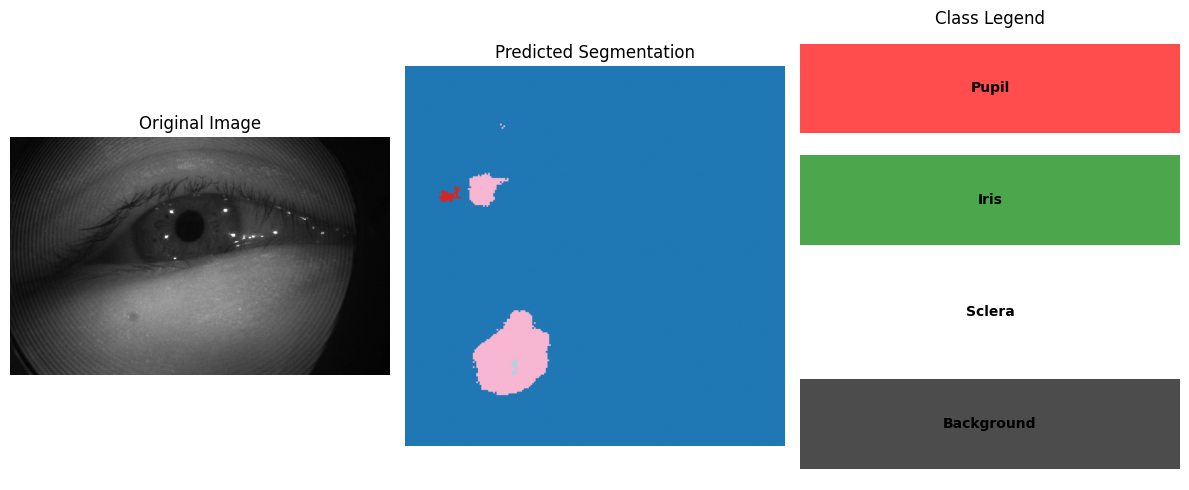

🎯 Starting Complete Model Visualization Pipeline
Extracting features from all layers...
✓ patch_extract_6: (1, 196, 256)
✓ patch_embedding_6: (1, 197, 768)


✓ adaptive_privacy_patch_drop_6: (1, 197, 768)


2025-09-21 17:46:23.764318: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10', 4 bytes spill stores, 4 bytes spill loads

2025-09-21 17:46:23.974536: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 8 bytes spill stores, 8 bytes spill loads

2025-09-21 17:46:24.397886: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10', 4 bytes spill stores, 4 bytes spill loads

2025-09-21 17:46:24.542953: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 8 bytes spill stores, 8 bytes spill loads

2025-09-21 17:46:24.549022: I external/local_xla/xla/strea

✓ transformer_block_48: (1, 197, 768)
✓ transformer_block_49: (1, 197, 768)
✓ transformer_block_50: (1, 197, 768)
✓ transformer_block_51: (1, 197, 768)
✓ transformer_block_52: (1, 197, 768)
✓ transformer_block_53: (1, 197, 768)
✓ transformer_block_54: (1, 197, 768)
✓ transformer_block_55: (1, 197, 768)
✓ layer_normalization_118: (1, 197, 768)
✓ differential_privacy_layer: (1, 197, 768)
✓ reshape_6: (1, 14, 14, 768)
✓ upsample_block_24: (1, 28, 28, 512)
✓ upsample_block_25: (1, 56, 56, 256)
✓ upsample_block_26: (1, 112, 112, 128)
✓ upsample_block_27: (1, 224, 224, 64)
✓ segmentation: (1, 224, 224, 4)

📸 Visualizing Patch Extraction...


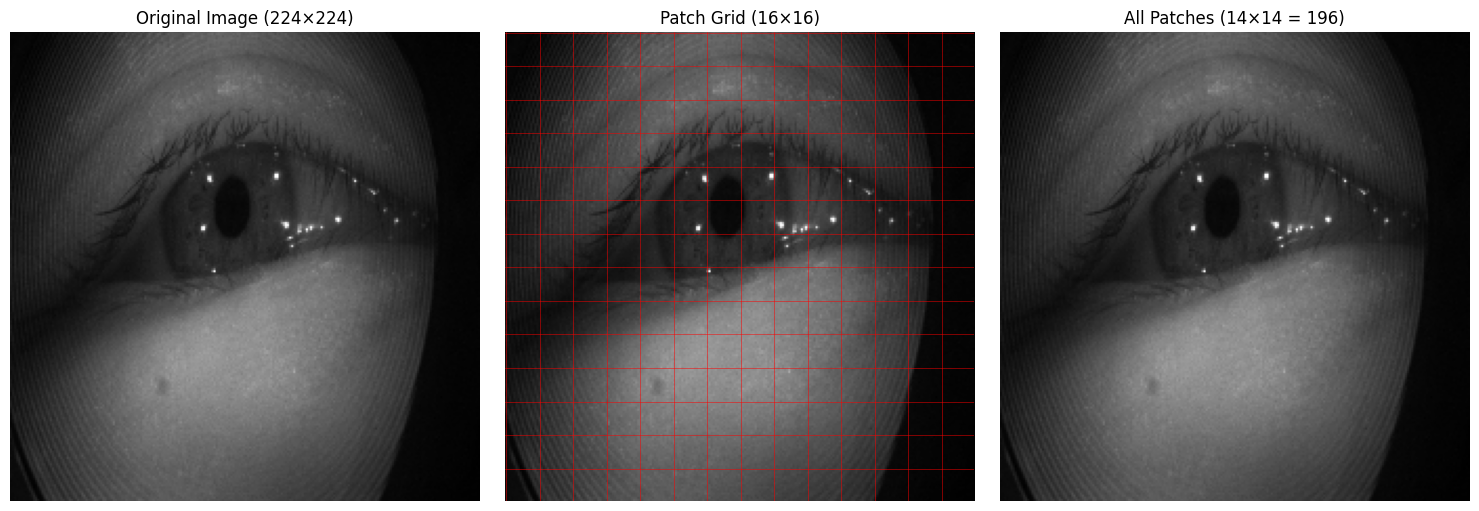


🔍 Visualizing Attention Patterns...


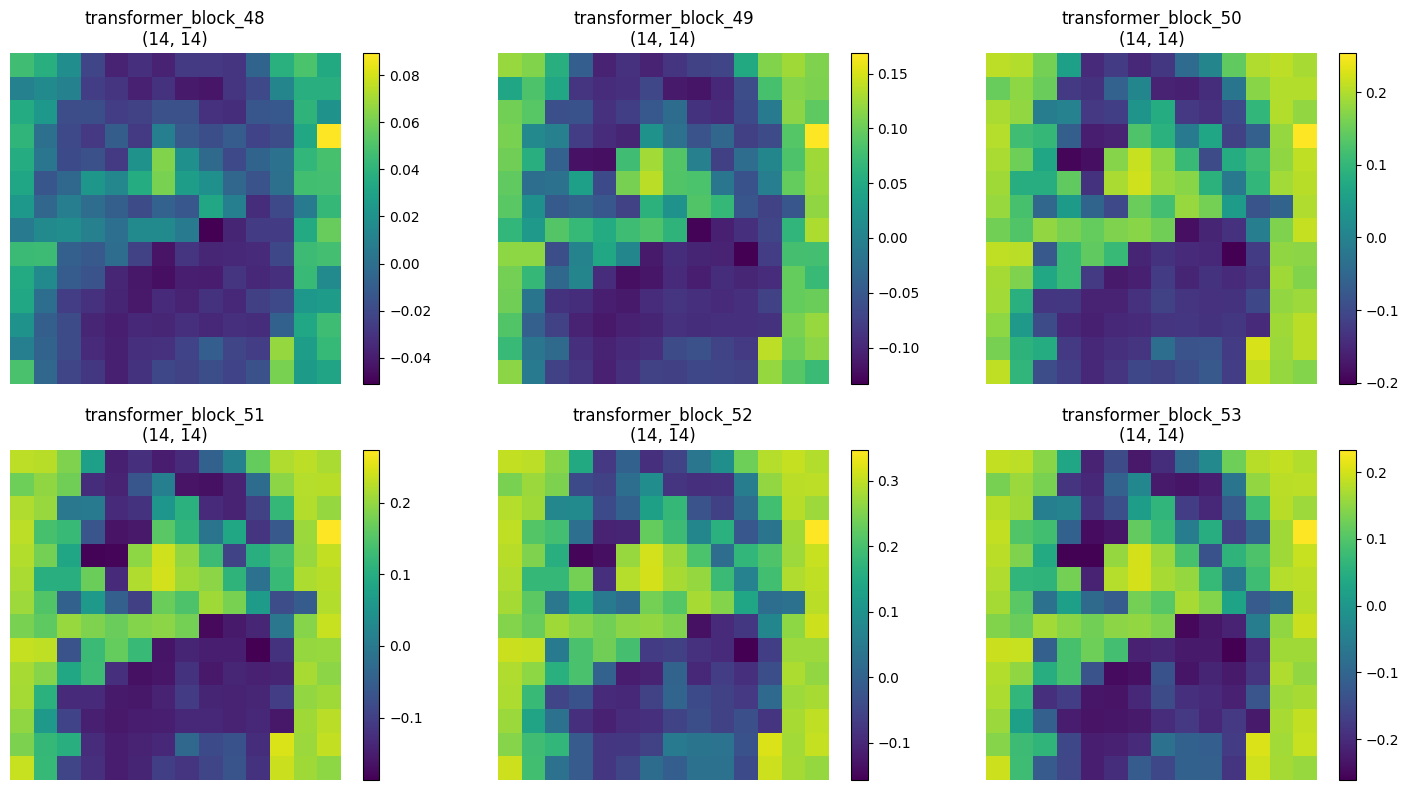


🔒 Visualizing Privacy Layers...


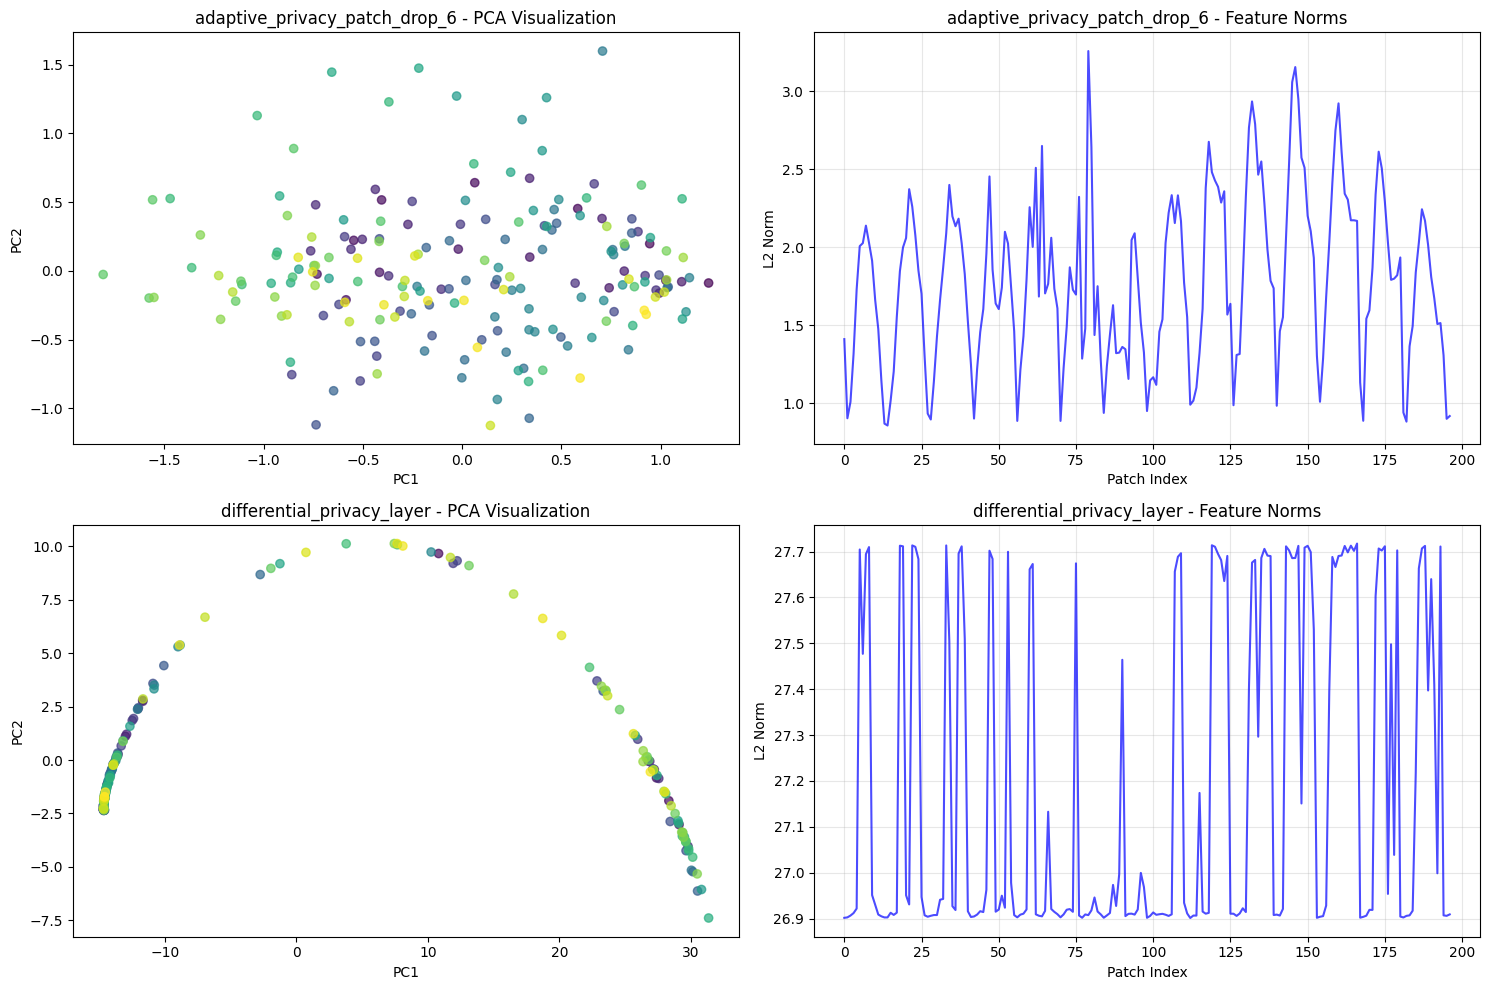


🔄 Visualizing Decoder Progression...


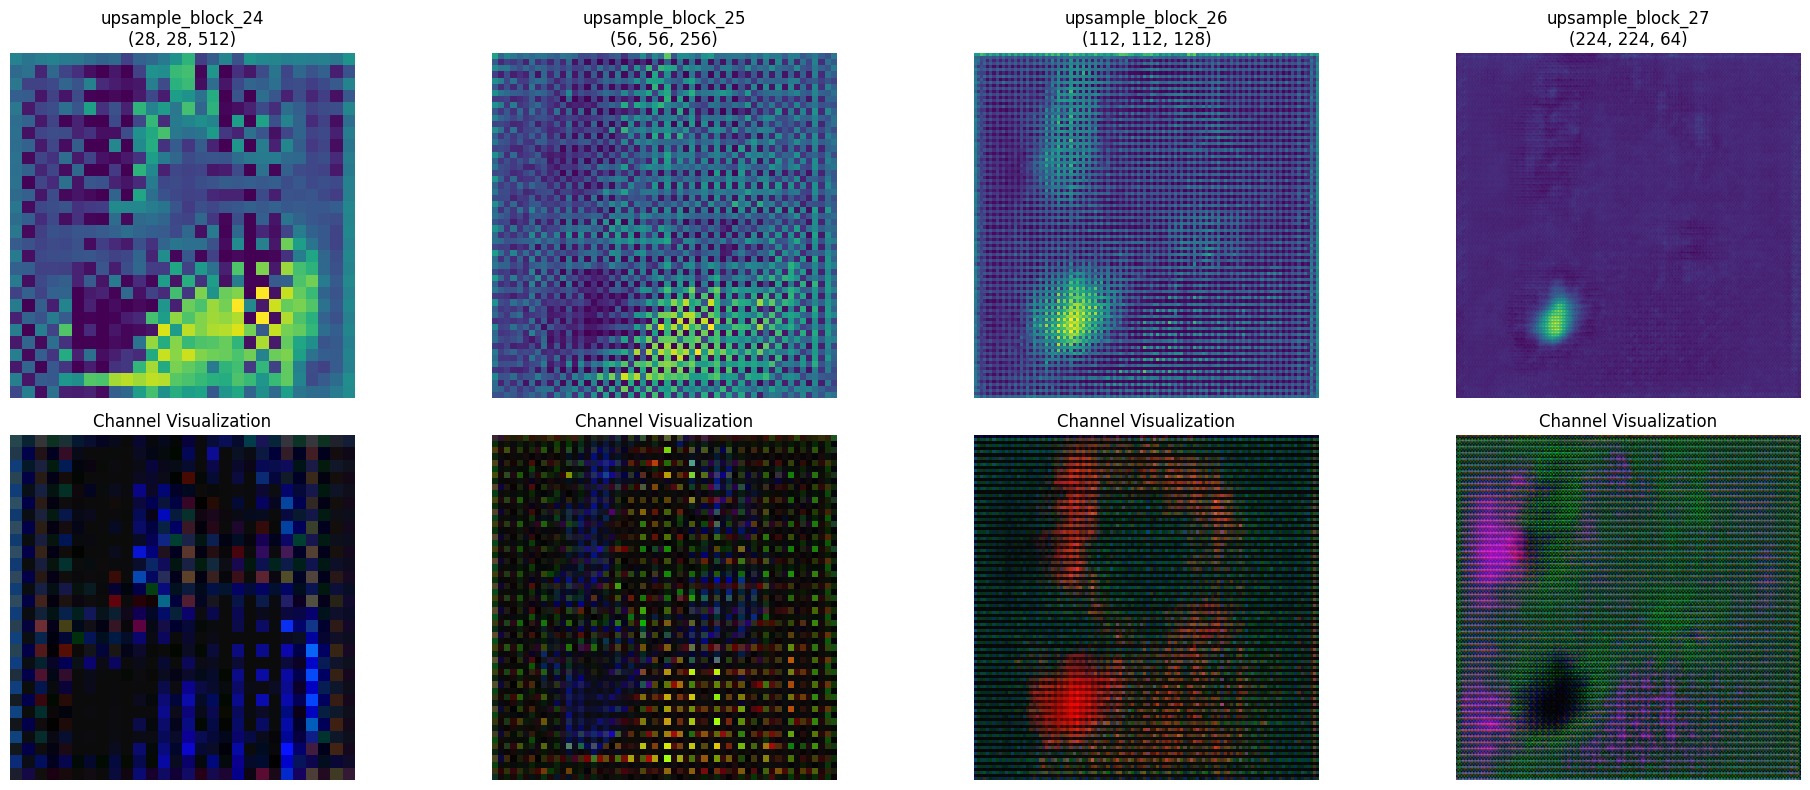


📊 Visualizing Feature Statistics...


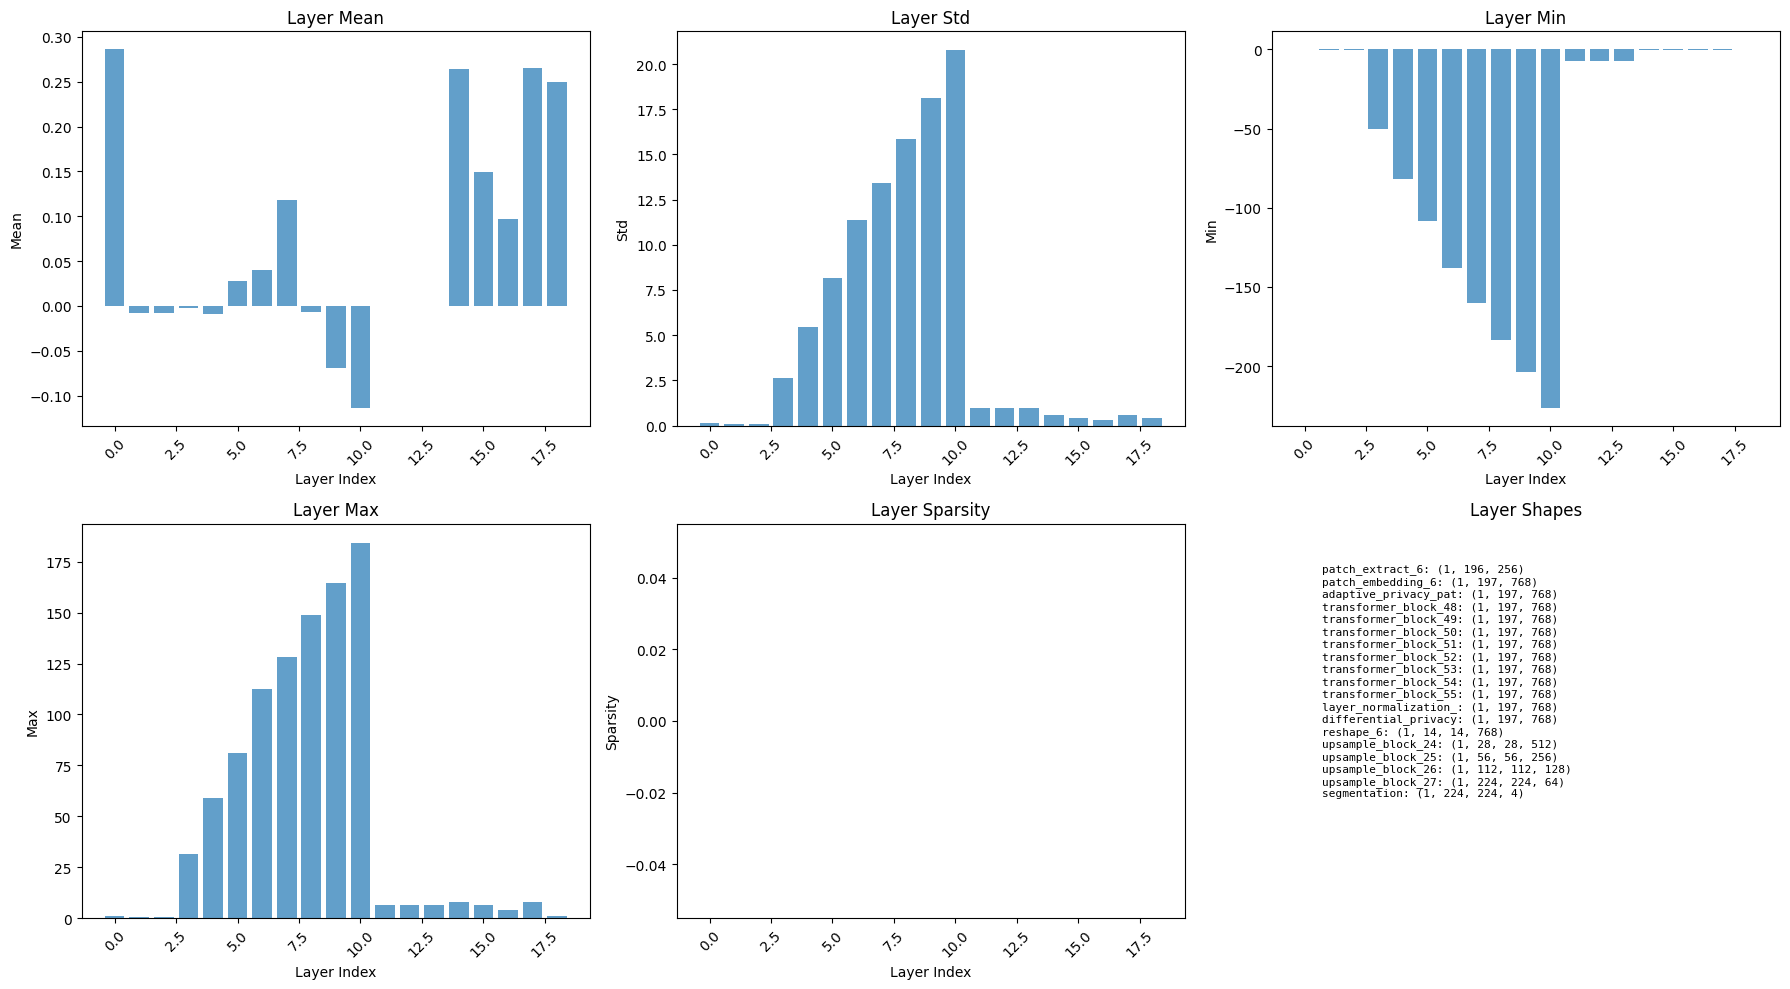


✅ Complete visualization finished!
Prediction completed! Mask shape: (224, 224)
Unique classes in prediction: [0 1 2 3]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.patches import Rectangle
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

class LayerVisualizationTool:
    """
    Comprehensive tool to visualize outputs from each layer of the ViT eye segmentation model
    """
    
    def __init__(self, model):
        self.model = model
        self.layer_outputs = {}
        self.feature_extractors = self._build_feature_extractors()
        
    def _build_feature_extractors(self):
        """Build feature extractors for each interesting layer"""
        extractors = {}
        
        # Get all layers
        for i, layer in enumerate(self.model.layers):
            layer_name = layer.name
            
            # Skip input layer and some intermediate layers that might cause issues
            if 'input' in layer_name.lower():
                continue
                
            try:
                # Create feature extractor for this layer
                extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=layer.output,
                    name=f"extractor_{layer_name}"
                )
                extractors[layer_name] = {
                    'extractor': extractor,
                    'layer_type': type(layer).__name__,
                    'layer_index': i
                }
            except Exception as e:
                print(f"Skipping layer {layer_name}: {str(e)}")
                
        return extractors
    
    def extract_all_features(self, image):
        """Extract features from all layers"""
        print("Extracting features from all layers...")
        
        for layer_name, layer_info in self.feature_extractors.items():
            try:
                features = layer_info['extractor'].predict(image, verbose=0)
                self.layer_outputs[layer_name] = {
                    'features': features,
                    'layer_type': layer_info['layer_type'],
                    'layer_index': layer_info['layer_index'],
                    'shape': features.shape
                }
                print(f"✓ {layer_name}: {features.shape}")
            except Exception as e:
                print(f"✗ Failed to extract from {layer_name}: {str(e)}")
    
    def visualize_patch_extraction(self, image, patch_size=16):
        """Visualize how the image is divided into patches"""
        plt.figure(figsize=(15, 5))
        
        # Original image
        plt.subplot(1, 3, 1)
        img_display = image[0].squeeze()
        plt.imshow(img_display, cmap='gray')
        plt.title('Original Image (224×224)')
        plt.axis('off')
        
        # Image with patch grid overlay
        plt.subplot(1, 3, 2)
        plt.imshow(img_display, cmap='gray')
        
        # Draw patch grid
        h, w = img_display.shape
        for i in range(0, h, patch_size):
            plt.axhline(y=i, color='red', linewidth=0.5, alpha=0.7)
        for j in range(0, w, patch_size):
            plt.axvline(x=j, color='red', linewidth=0.5, alpha=0.7)
        
        plt.title(f'Patch Grid ({patch_size}×{patch_size})')
        plt.axis('off')
        
        # Show some individual patches
        plt.subplot(1, 3, 3)
        patches_per_row = h // patch_size
        patches_per_col = w // patch_size
        
        # Create a visualization of all patches
        patch_mosaic = np.zeros((patches_per_row * patch_size, patches_per_col * patch_size))
        
        for i in range(patches_per_row):
            for j in range(patches_per_col):
                patch = img_display[i*patch_size:(i+1)*patch_size, 
                                  j*patch_size:(j+1)*patch_size]
                patch_mosaic[i*patch_size:(i+1)*patch_size,
                           j*patch_size:(j+1)*patch_size] = patch
        
        plt.imshow(patch_mosaic, cmap='gray')
        plt.title(f'All Patches ({patches_per_row}×{patches_per_col} = {patches_per_row*patches_per_col})')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_attention_patterns(self):
        """Visualize attention patterns from transformer layers"""
        attention_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if 'attention' in layer_name.lower() or 'transformer' in layer_name.lower():
                attention_layers.append((layer_name, output_info))
        
        if not attention_layers:
            print("No attention layers found for visualization")
            return
        
        # Visualize attention patterns
        fig, axes = plt.subplots(2, min(3, len(attention_layers)), figsize=(15, 8))
        if len(attention_layers) == 1:
            axes = axes.reshape(2, 1)
        
        for idx, (layer_name, output_info) in enumerate(attention_layers[:6]):
            if idx >= 6:
                break
                
            features = output_info['features'][0]  # Remove batch dimension
            
            # Reshape if needed (remove class token if present)
            if len(features.shape) == 2:  # (seq_len, embed_dim)
                if features.shape[0] == 197:  # 196 patches + 1 class token
                    features = features[1:]  # Remove class token
                
                # Reshape to spatial dimensions
                spatial_size = int(np.sqrt(features.shape[0]))
                if spatial_size * spatial_size == features.shape[0]:
                    # Average across embedding dimension for visualization
                    spatial_features = features.mean(axis=-1)
                    spatial_features = spatial_features.reshape(spatial_size, spatial_size)
                    
                    row = idx // 3
                    col = idx % 3
                    
                    if len(attention_layers) <= 3:
                        ax = axes[row] if axes.ndim == 1 else axes[row, col]
                    else:
                        ax = axes[row, col] if axes.ndim == 2 else axes[idx]
                    
                    im = ax.imshow(spatial_features, cmap='viridis')
                    ax.set_title(f'{layer_name}\n{spatial_features.shape}')
                    ax.axis('off')
                    plt.colorbar(im, ax=ax, fraction=0.046)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_privacy_layers(self):
        """Visualize privacy-preserving layer outputs"""
        privacy_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if 'privacy' in layer_name.lower() or 'adaptive' in layer_name.lower():
                privacy_layers.append((layer_name, output_info))
        
        if not privacy_layers:
            print("No privacy layers found")
            return
        
        plt.figure(figsize=(15, 10))
        
        for idx, (layer_name, output_info) in enumerate(privacy_layers):
            features = output_info['features'][0]  # Remove batch dimension
            
            if len(features.shape) == 2:  # (seq_len, embed_dim)
                # Show first few dimensions of embeddings
                plt.subplot(len(privacy_layers), 2, idx*2 + 1)
                
                # PCA for visualization if embedding dim > 3
                if features.shape[-1] > 3:
                    pca = PCA(n_components=min(3, features.shape[-1]))
                    features_pca = pca.fit_transform(features)
                    plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                              c=range(len(features_pca)), cmap='viridis', alpha=0.7)
                    plt.title(f'{layer_name} - PCA Visualization')
                    plt.xlabel('PC1')
                    plt.ylabel('PC2')
                else:
                    plt.imshow(features.T, aspect='auto', cmap='viridis')
                    plt.title(f'{layer_name} - Feature Map')
                    plt.xlabel('Sequence Position')
                    plt.ylabel('Embedding Dimension')
                
                # Show embedding statistics
                plt.subplot(len(privacy_layers), 2, idx*2 + 2)
                feature_norms = np.linalg.norm(features, axis=-1)
                plt.plot(feature_norms, 'b-', alpha=0.7)
                plt.title(f'{layer_name} - Feature Norms')
                plt.xlabel('Patch Index')
                plt.ylabel('L2 Norm')
                plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_decoder_progression(self):
        """Visualize how the decoder upsamples features"""
        decoder_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if ('upsample' in layer_name.lower() or 
                'conv2d_transpose' in layer_name.lower() or
                'decoder' in layer_name.lower()):
                decoder_layers.append((layer_name, output_info))
        
        if not decoder_layers:
            print("No decoder layers found")
            return
        
        # Sort by layer index to show progression
        decoder_layers.sort(key=lambda x: x[1]['layer_index'])
        
        plt.figure(figsize=(20, 8))
        
        for idx, (layer_name, output_info) in enumerate(decoder_layers):
            features = output_info['features'][0]  # Remove batch dimension
            
            if len(features.shape) == 3:  # (H, W, C)
                # Average across channels for visualization
                feature_map = features.mean(axis=-1)
                
                plt.subplot(2, len(decoder_layers), idx + 1)
                plt.imshow(feature_map, cmap='viridis')
                plt.title(f'{layer_name}\n{features.shape}')
                plt.axis('off')
                
                # Show some individual channels
                plt.subplot(2, len(decoder_layers), len(decoder_layers) + idx + 1)
                if features.shape[-1] >= 3:
                    # Show RGB-like visualization of first 3 channels
                    rgb_vis = features[:, :, :3]
                    rgb_vis = (rgb_vis - rgb_vis.min()) / (rgb_vis.max() - rgb_vis.min())
                    plt.imshow(rgb_vis)
                else:
                    plt.imshow(features[:, :, 0], cmap='viridis')
                plt.title(f'Channel Visualization')
                plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_feature_statistics(self):
        """Show statistics of features across layers"""
        layer_names = []
        layer_shapes = []
        param_counts = []
        activation_stats = []
        
        for layer_name, output_info in self.layer_outputs.items():
            features = output_info['features']
            
            layer_names.append(layer_name[:20])  # Truncate long names
            layer_shapes.append(str(features.shape))
            
            # Calculate statistics
            stats = {
                'mean': np.mean(features),
                'std': np.std(features),
                'min': np.min(features),
                'max': np.max(features),
                'sparsity': np.mean(features == 0) * 100
            }
            activation_stats.append(stats)
        
        # Create statistics visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        stats_keys = ['mean', 'std', 'min', 'max', 'sparsity']
        
        for idx, stat_key in enumerate(stats_keys):
            row = idx // 3
            col = idx % 3
            
            values = [stats[stat_key] for stats in activation_stats]
            
            axes[row, col].bar(range(len(values)), values, alpha=0.7)
            axes[row, col].set_title(f'Layer {stat_key.capitalize()}')
            axes[row, col].set_xlabel('Layer Index')
            axes[row, col].set_ylabel(stat_key.capitalize())
            axes[row, col].tick_params(axis='x', rotation=45)
            
            # Add layer names on x-axis
            if len(layer_names) <= 10:
                axes[row, col].set_xticks(range(len(layer_names)))
                axes[row, col].set_xticklabels(layer_names, rotation=45, ha='right')
        
        # Layer shapes info
        axes[1, 2].axis('off')
        shape_text = "\n".join([f"{name}: {shape}" for name, shape in zip(layer_names, layer_shapes)])
        axes[1, 2].text(0.1, 0.9, shape_text, transform=axes[1, 2].transAxes, 
                        fontsize=8, verticalalignment='top', fontfamily='monospace')
        axes[1, 2].set_title('Layer Shapes')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_complete_pipeline(self, image, save_plots=False):
        """Complete visualization of the entire model pipeline"""
        print("🎯 Starting Complete Model Visualization Pipeline")
        print("=" * 60)
        
        # 1. Extract features from all layers
        self.extract_all_features(image)
        
        # 2. Visualize patch extraction
        print("\n📸 Visualizing Patch Extraction...")
        self.visualize_patch_extraction(image)
        
        # 3. Visualize attention patterns
        print("\n🔍 Visualizing Attention Patterns...")
        self.visualize_attention_patterns()
        
        # 4. Visualize privacy layers
        print("\n🔒 Visualizing Privacy Layers...")
        self.visualize_privacy_layers()
        
        # 5. Visualize decoder progression
        print("\n🔄 Visualizing Decoder Progression...")
        self.visualize_decoder_progression()
        
        # 6. Show feature statistics
        print("\n📊 Visualizing Feature Statistics...")
        self.visualize_feature_statistics()
        
        print("\n✅ Complete visualization finished!")

def load_and_predict_with_visualization(model, image_path):
    """Load image, predict, and visualize everything"""
    
    # Load and preprocess image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(image, (224, 224))
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    # img = img.astype(np.float32) / 255.0  # Normalize
    
    # Predict
    predicted_mask = model.predict(img)
    predicted_mask = np.argmax(predicted_mask, axis=-1)[0]
    
    # Show final prediction
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(predicted_mask, cmap='tab20')
    plt.title('Predicted Segmentation')
    plt.axis('off')
    
    # Color legend
    plt.subplot(1, 3, 3)
    colors = ['black', 'white', 'green', 'red']
    labels = ['Background', 'Sclera', 'Iris', 'Pupil']
    for i, (color, label) in enumerate(zip(colors, labels)):
        plt.barh(i, 1, color=color, alpha=0.7)
        plt.text(0.5, i, label, ha='center', va='center', fontweight='bold')
    plt.xlim(0, 1)
    plt.ylim(-0.5, len(labels)-0.5)
    plt.axis('off')
    plt.title('Class Legend')
    
    plt.tight_layout()
    plt.show()
    
    # Create visualization tool and run complete pipeline
    viz_tool = LayerVisualizationTool(model)
    viz_tool.visualize_complete_pipeline(img)
    
    return predicted_mask, viz_tool

# Usage example
if __name__ == "__main__":
    # Your existing code
    image_path = './openEDS/openEDS/S_15/100.png'
    
    # Assuming you have your model loaded
    # model = your_trained_model
    
    # Run complete visualization
    predicted_mask, viz_tool = load_and_predict_with_visualization(model, image_path)
    
    print(f"Prediction completed! Mask shape: {predicted_mask.shape}")
    print(f"Unique classes in prediction: {np.unique(predicted_mask)}")

Found Adaptive Patch Drop layer: adaptive_privacy_patch_drop_6
🎯 Visualizing Adaptive Privacy Patch Dropout Layer

📸 Analyzing single image patch sensitivity and dropout...


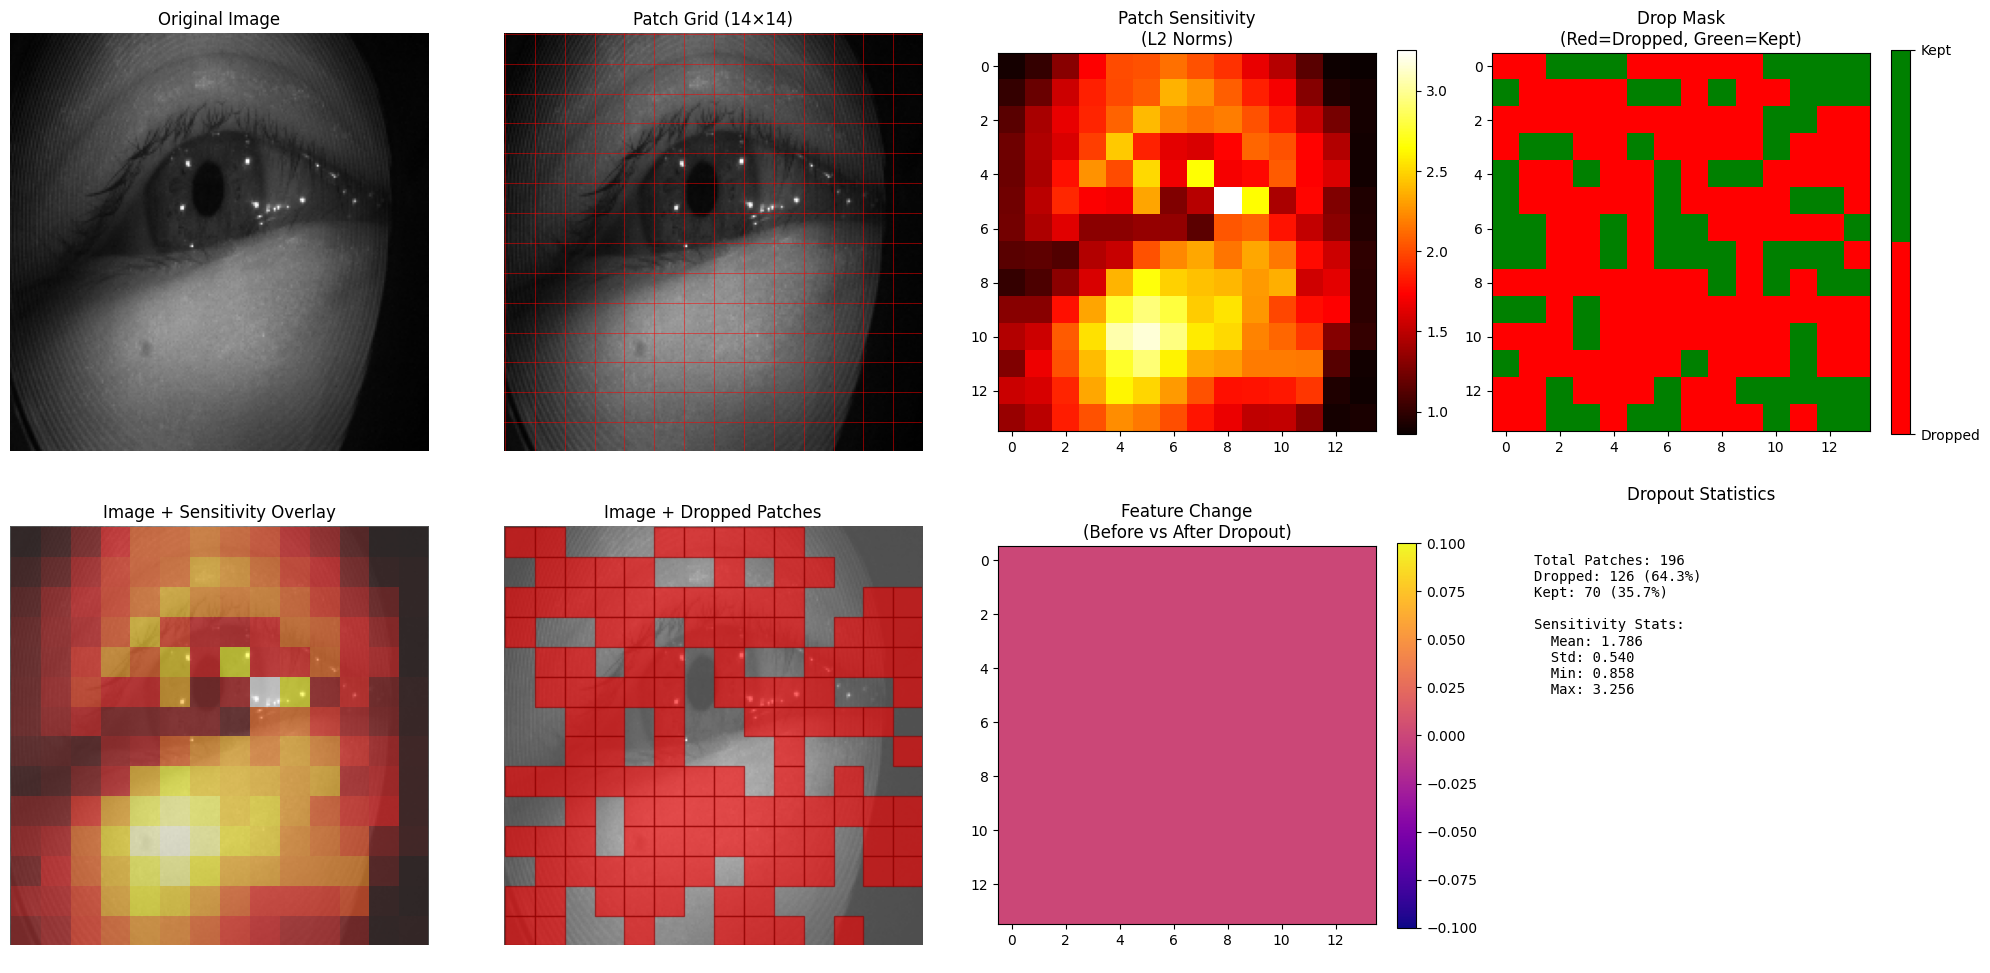


📊 Analyzing batch of 5 images for privacy effectiveness...
🔒 Analyzing Privacy Effectiveness of Adaptive Patch Dropout


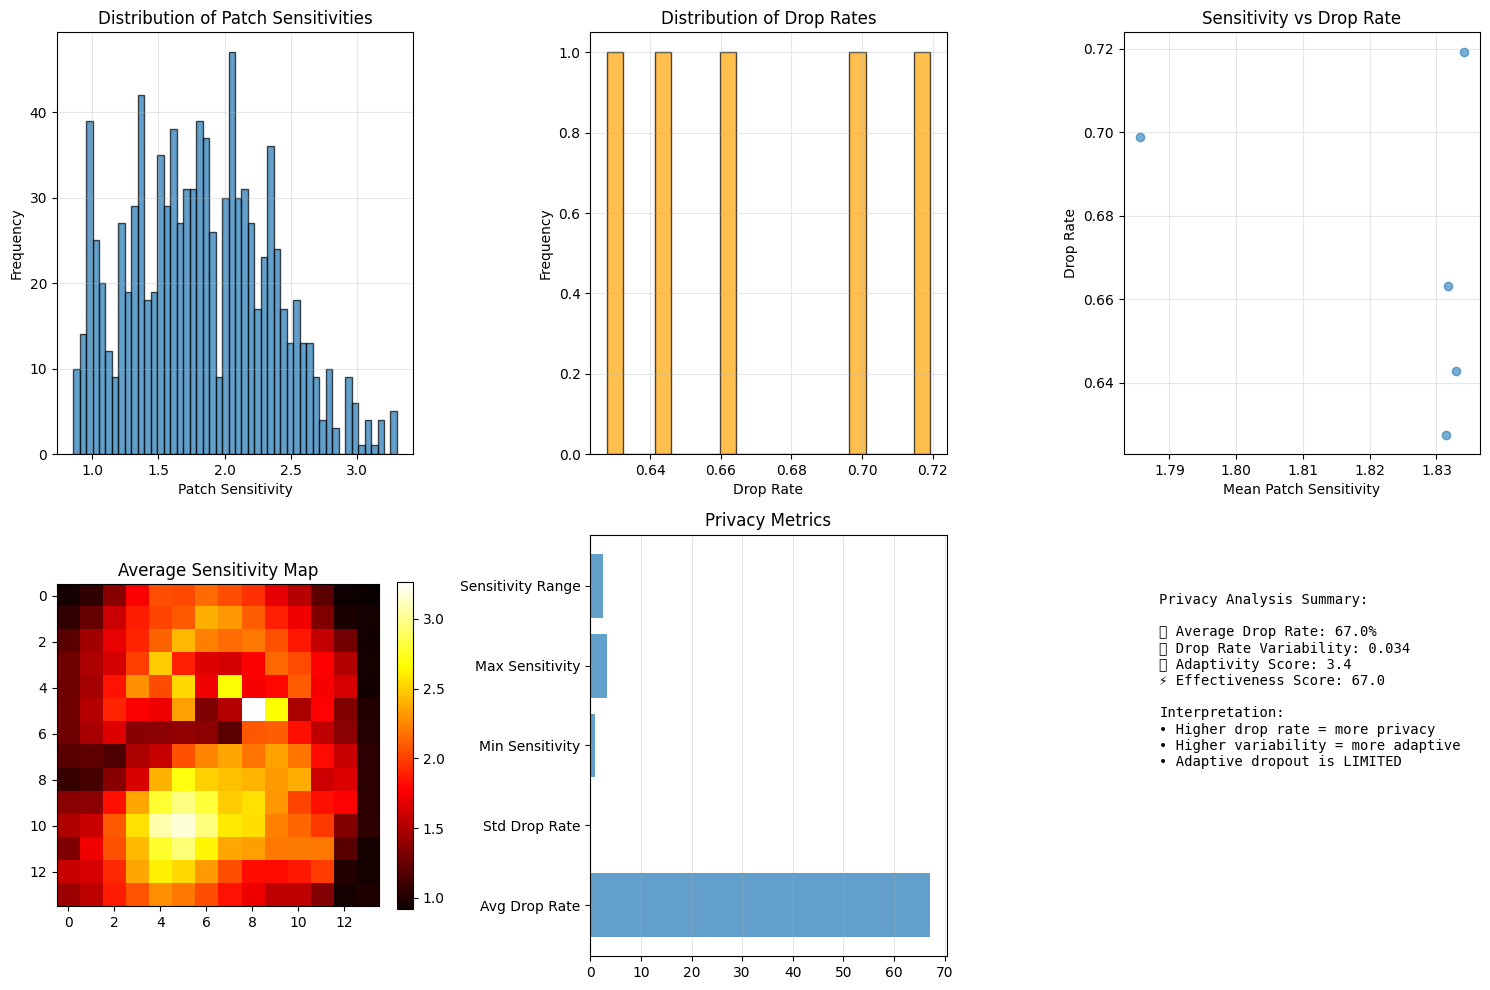


✅ Privacy Analysis Complete!
   Average Drop Rate: 67.0%
   Adaptivity Score: 3.42
   Effectiveness Score: 67.04


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

class AdaptivePatchDropVisualizer:
    """
    Specialized visualizer for Adaptive Privacy Patch Drop layer
    Shows which patches are dropped, sensitivity maps, and privacy analysis
    """
    
    def __init__(self, model):
        self.model = model
        self.patch_drop_layer = None
        self.patch_drop_extractor = None
        self.patch_extractor = None
        self.patch_embedding_extractor = None
        self._find_patch_drop_layer()
        
    def _find_patch_drop_layer(self):
        """Find the AdaptivePrivacyPatchDrop layer in the model"""
        for layer in self.model.layers:
            if 'adaptive' in layer.name.lower() and 'drop' in layer.name.lower():
                self.patch_drop_layer = layer
                print(f"Found Adaptive Patch Drop layer: {layer.name}")
                break
        
        if self.patch_drop_layer is None:
            print("❌ AdaptivePrivacyPatchDrop layer not found!")
            return
        
        # Build extractors for different stages
        self._build_extractors()
    
    def _build_extractors(self):
        """Build feature extractors for patch analysis"""
        try:
            # Find patch extraction layer
            patch_extract_layer = None
            patch_embedding_layer = None
            
            for layer in self.model.layers:
                if 'patch' in layer.name.lower() and 'extract' in layer.name.lower():
                    patch_extract_layer = layer
                elif 'patch' in layer.name.lower() and 'embedding' in layer.name.lower():
                    patch_embedding_layer = layer
            
            # Create extractors
            if patch_extract_layer:
                self.patch_extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=patch_extract_layer.output
                )
            
            if patch_embedding_layer:
                self.patch_embedding_extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=patch_embedding_layer.output
                )
            
            # Extractor for patch drop layer output
            self.patch_drop_extractor = tf.keras.Model(
                inputs=self.model.input,
                outputs=self.patch_drop_layer.output
            )
            
        except Exception as e:
            print(f"Error building extractors: {e}")
    
    def extract_patch_features(self, image):
        """Extract features at different stages of patch processing"""
        features = {}
        
        try:
            # Original patches
            if self.patch_extractor:
                features['raw_patches'] = self.patch_extractor.predict(image, verbose=0)
            
            # Embedded patches (before dropout)
            if self.patch_embedding_extractor:
                features['embedded_patches'] = self.patch_embedding_extractor.predict(image, verbose=0)
            
            # After patch dropout
            if self.patch_drop_extractor:
                features['dropped_patches'] = self.patch_drop_extractor.predict(image, verbose=0)
            
        except Exception as e:
            print(f"Error extracting features: {e}")
        
        return features
    
    def get_drop_mask_and_sensitivity(self, image):
        """
        Extract the actual drop mask and sensitivity scores from the layer
        This requires modifying the layer to expose intermediate values
        """
        # Create a modified version of the model that outputs intermediate values
        try:
            # We need to access the layer's internal state
            # This is a bit hacky but necessary to visualize the drop patterns
            
            # Get the layer's weights (sensitivity weights)
            if hasattr(self.patch_drop_layer, 'sensitivity_weights'):
                sensitivity_weights = self.patch_drop_layer.sensitivity_weights.numpy()
            else:
                sensitivity_weights = None
            
            # To get the actual mask, we need to run the model in training mode
            # and access the layer's last_mask attribute
            
            # Set training mode
            with tf.GradientTape() as tape:
                _ = self.model(image, training=True)
            
            # Get the last mask if available
            drop_mask = None
            if hasattr(self.patch_drop_layer, 'last_mask') and self.patch_drop_layer.last_mask is not None:
                drop_mask = self.patch_drop_layer.last_mask.numpy()
            
            return drop_mask, sensitivity_weights
            
        except Exception as e:
            print(f"Error getting drop mask: {e}")
            return None, None
    
    def visualize_patch_sensitivity(self, image, patch_size=16):
        """Visualize patch sensitivity and drop patterns"""
        
        # Extract features
        features = self.extract_patch_features(image)
        drop_mask, sensitivity_weights = self.get_drop_mask_and_sensitivity(image)
        
        if not features:
            print("No features extracted!")
            return
        
        # Calculate spatial dimensions
        img_size = 224
        patches_per_side = img_size // patch_size
        
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        
        # 1. Original Image
        img_display = image[0].squeeze()
        axes[0, 0].imshow(img_display, cmap='gray')
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')
        
        # 2. Patch Grid
        axes[0, 1].imshow(img_display, cmap='gray')
        self._draw_patch_grid(axes[0, 1], img_size, patch_size)
        axes[0, 1].set_title(f'Patch Grid ({patches_per_side}×{patches_per_side})')
        axes[0, 1].axis('off')
        
        # 3. Patch Sensitivity Heatmap
        if 'embedded_patches' in features:
            embedded = features['embedded_patches'][0]  # Remove batch dim
            if embedded.shape[0] == 197:  # Remove class token if present
                embedded = embedded[1:]
            
            # Calculate patch norms as sensitivity proxy
            patch_norms = np.linalg.norm(embedded, axis=-1)
            sensitivity_map = patch_norms.reshape(patches_per_side, patches_per_side)
            
            im1 = axes[0, 2].imshow(sensitivity_map, cmap='hot', interpolation='nearest')
            axes[0, 2].set_title('Patch Sensitivity\n(L2 Norms)')
            plt.colorbar(im1, ax=axes[0, 2], fraction=0.046)
            
        # 4. Drop Mask Visualization
        if drop_mask is not None:
            # drop_mask shape: (batch, num_patches, 1)
            mask_2d = drop_mask[0, :, 0]  # Remove batch and channel dims
            if len(mask_2d) == 197:  # Remove class token if present
                mask_2d = mask_2d[1:]
            
            mask_spatial = mask_2d.reshape(patches_per_side, patches_per_side)
            
            # Create custom colormap: dropped=red, kept=green
            colors = ['red', 'green']
            cmap = ListedColormap(colors)
            
            im2 = axes[0, 3].imshow(mask_spatial, cmap=cmap, vmin=0, vmax=1)
            axes[0, 3].set_title('Drop Mask\n(Red=Dropped, Green=Kept)')
            cbar = plt.colorbar(im2, ax=axes[0, 3], fraction=0.046, ticks=[0, 1])
            cbar.ax.set_yticklabels(['Dropped', 'Kept'])
        else:
            axes[0, 3].text(0.5, 0.5, 'Drop mask\nnot available', 
                           ha='center', va='center', transform=axes[0, 3].transAxes)
            axes[0, 3].set_title('Drop Mask')
        
        # 5. Overlay: Original + Sensitivity
        axes[1, 0].imshow(img_display, cmap='gray', alpha=0.7)
        if 'embedded_patches' in features:
            # Overlay sensitivity as colored patches
            self._overlay_patch_values(axes[1, 0], sensitivity_map, patch_size, alpha=0.5, cmap='hot')
        axes[1, 0].set_title('Image + Sensitivity Overlay')
        axes[1, 0].axis('off')
        
        # 6. Overlay: Original + Drop Mask
        axes[1, 1].imshow(img_display, cmap='gray', alpha=0.7)
        if drop_mask is not None:
            # Overlay dropped patches in red
            self._overlay_dropped_patches(axes[1, 1], mask_spatial, patch_size)
        axes[1, 1].set_title('Image + Dropped Patches')
        axes[1, 1].axis('off')
        
        # 7. Feature Comparison: Before vs After Dropout
        if 'embedded_patches' in features and 'dropped_patches' in features:
            before = features['embedded_patches'][0]
            after = features['dropped_patches'][0]
            
            if before.shape[0] == 197:  # Remove class token
                before = before[1:]
            if after.shape[0] == 197:
                after = after[1:]
            
            # Calculate difference
            diff = np.linalg.norm(before - after, axis=-1)
            diff_map = diff.reshape(patches_per_side, patches_per_side)
            
            im3 = axes[1, 2].imshow(diff_map, cmap='plasma', interpolation='nearest')
            axes[1, 2].set_title('Feature Change\n(Before vs After Dropout)')
            plt.colorbar(im3, ax=axes[1, 2], fraction=0.046)
        
        # 8. Statistics
        axes[1, 3].axis('off')
        stats_text = self._calculate_dropout_statistics(features, drop_mask)
        axes[1, 3].text(0.1, 0.9, stats_text, transform=axes[1, 3].transAxes,
                       fontsize=10, verticalalignment='top', fontfamily='monospace')
        axes[1, 3].set_title('Dropout Statistics')
        
        plt.tight_layout()
        plt.show()
    
    def _draw_patch_grid(self, ax, img_size, patch_size):
        """Draw patch grid overlay"""
        for i in range(0, img_size, patch_size):
            ax.axhline(y=i, color='red', linewidth=0.5, alpha=0.7)
            ax.axvline(x=i, color='red', linewidth=0.5, alpha=0.7)
    
    def _overlay_patch_values(self, ax, values, patch_size, alpha=0.5, cmap='hot'):
        """Overlay patch values on image"""
        patches_per_side = values.shape[0]
        for i in range(patches_per_side):
            for j in range(patches_per_side):
                value = values[i, j]
                normalized_value = (value - values.min()) / (values.max() - values.min())
                
                rect = Rectangle((j * patch_size, i * patch_size), 
                               patch_size, patch_size,
                               facecolor=plt.cm.get_cmap(cmap)(normalized_value),
                               alpha=alpha)
                ax.add_patch(rect)
    
    def _overlay_dropped_patches(self, ax, mask, patch_size):
        """Overlay dropped patches in red"""
        patches_per_side = mask.shape[0]
        for i in range(patches_per_side):
            for j in range(patches_per_side):
                if mask[i, j] == 0:  # Dropped patch
                    rect = Rectangle((j * patch_size, i * patch_size), 
                                   patch_size, patch_size,
                                   facecolor='red', alpha=0.6, edgecolor='darkred')
                    ax.add_patch(rect)
    
    def _calculate_dropout_statistics(self, features, drop_mask):
        """Calculate and format dropout statistics"""
        stats = []
        
        if drop_mask is not None:
            mask = drop_mask[0, :, 0]  # Remove batch and channel dims
            if len(mask) == 197:  # Remove class token
                mask = mask[1:]
            
            total_patches = len(mask)
            dropped_patches = np.sum(mask == 0)
            kept_patches = np.sum(mask == 1)
            drop_rate = dropped_patches / total_patches * 100
            
            stats.append(f"Total Patches: {total_patches}")
            stats.append(f"Dropped: {dropped_patches} ({drop_rate:.1f}%)")
            stats.append(f"Kept: {kept_patches} ({100-drop_rate:.1f}%)")
            stats.append("")
        
        if 'embedded_patches' in features:
            embedded = features['embedded_patches'][0]
            if embedded.shape[0] == 197:
                embedded = embedded[1:]
            
            patch_norms = np.linalg.norm(embedded, axis=-1)
            stats.append(f"Sensitivity Stats:")
            stats.append(f"  Mean: {patch_norms.mean():.3f}")
            stats.append(f"  Std: {patch_norms.std():.3f}")
            stats.append(f"  Min: {patch_norms.min():.3f}")
            stats.append(f"  Max: {patch_norms.max():.3f}")
        
        return "\n".join(stats)
    
    def analyze_privacy_effectiveness(self, images_batch, labels=None):
        """
        Analyze how effective the patch dropout is for privacy
        """
        print("🔒 Analyzing Privacy Effectiveness of Adaptive Patch Dropout")
        print("=" * 60)
        
        all_sensitivities = []
        all_drop_rates = []
        
        for i, image in enumerate(images_batch):
            image_batch = np.expand_dims(image, axis=0)
            
            # Extract features
            features = self.extract_patch_features(image_batch)
            drop_mask, _ = self.get_drop_mask_and_sensitivity(image_batch)
            
            if 'embedded_patches' in features and drop_mask is not None:
                embedded = features['embedded_patches'][0]
                if embedded.shape[0] == 197:
                    embedded = embedded[1:]
                
                mask = drop_mask[0, :, 0]
                if len(mask) == 197:
                    mask = mask[1:]
                
                # Calculate sensitivity
                patch_sensitivity = np.linalg.norm(embedded, axis=-1)
                all_sensitivities.append(patch_sensitivity)
                
                # Calculate drop rate
                drop_rate = np.sum(mask == 0) / len(mask)
                all_drop_rates.append(drop_rate)
        
        if all_sensitivities:
            # Analyze patterns
            plt.figure(figsize=(15, 10))
            
            # 1. Sensitivity distribution
            plt.subplot(2, 3, 1)
            all_sens_flat = np.concatenate(all_sensitivities)
            plt.hist(all_sens_flat, bins=50, alpha=0.7, edgecolor='black')
            plt.xlabel('Patch Sensitivity')
            plt.ylabel('Frequency')
            plt.title('Distribution of Patch Sensitivities')
            plt.grid(True, alpha=0.3)
            
            # 2. Drop rate distribution
            plt.subplot(2, 3, 2)
            plt.hist(all_drop_rates, bins=20, alpha=0.7, edgecolor='black', color='orange')
            plt.xlabel('Drop Rate')
            plt.ylabel('Frequency')
            plt.title('Distribution of Drop Rates')
            plt.grid(True, alpha=0.3)
            
            # 3. Sensitivity vs Drop Rate correlation
            plt.subplot(2, 3, 3)
            mean_sensitivities = [np.mean(sens) for sens in all_sensitivities]
            plt.scatter(mean_sensitivities, all_drop_rates, alpha=0.6)
            plt.xlabel('Mean Patch Sensitivity')
            plt.ylabel('Drop Rate')
            plt.title('Sensitivity vs Drop Rate')
            plt.grid(True, alpha=0.3)
            
            # 4. Spatial pattern analysis
            plt.subplot(2, 3, 4)
            if len(all_sensitivities) > 0:
                # Average sensitivity across all images
                avg_sensitivity = np.mean(all_sensitivities, axis=0)
                patches_per_side = int(np.sqrt(len(avg_sensitivity)))
                sensitivity_map = avg_sensitivity.reshape(patches_per_side, patches_per_side)
                
                im = plt.imshow(sensitivity_map, cmap='hot', interpolation='nearest')
                plt.title('Average Sensitivity Map')
                plt.colorbar(im, fraction=0.046)
            
            # 5. Privacy metrics
            plt.subplot(2, 3, 5)
            privacy_metrics = {
                'Avg Drop Rate': f"{np.mean(all_drop_rates):.2%}",
                'Std Drop Rate': f"{np.std(all_drop_rates):.3f}",
                'Min Sensitivity': f"{np.min(all_sens_flat):.3f}",
                'Max Sensitivity': f"{np.max(all_sens_flat):.3f}",
                'Sensitivity Range': f"{np.max(all_sens_flat) - np.min(all_sens_flat):.3f}"
            }
            
            y_pos = np.arange(len(privacy_metrics))
            plt.barh(y_pos, [float(v.strip('%')) if '%' in v else float(v) 
                           for v in privacy_metrics.values()], alpha=0.7)
            plt.yticks(y_pos, privacy_metrics.keys())
            plt.title('Privacy Metrics')
            plt.grid(True, alpha=0.3, axis='x')
            
            # 6. Effectiveness summary
            plt.subplot(2, 3, 6)
            plt.axis('off')
            
            effectiveness_score = np.mean(all_drop_rates) * 100
            adaptivity_score = np.std(all_drop_rates) * 100
            
            summary_text = f"""
Privacy Analysis Summary:

🎯 Average Drop Rate: {np.mean(all_drop_rates):.1%}
📊 Drop Rate Variability: {np.std(all_drop_rates):.3f}
🔄 Adaptivity Score: {adaptivity_score:.1f}
⚡ Effectiveness Score: {effectiveness_score:.1f}

Interpretation:
• Higher drop rate = more privacy
• Higher variability = more adaptive
• Adaptive dropout is {'WORKING' if adaptivity_score > 5 else 'LIMITED'}
            """
            
            plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes,
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
            
            plt.tight_layout()
            plt.show()
            
            return {
                'mean_drop_rate': np.mean(all_drop_rates),
                'std_drop_rate': np.std(all_drop_rates),
                'mean_sensitivity': np.mean(all_sens_flat),
                'adaptivity_score': adaptivity_score,
                'effectiveness_score': effectiveness_score
            }
        
        return None

# Enhanced usage function
def visualize_adaptive_patch_dropout_complete(model, image_path, num_samples=5):
    """
    Complete visualization of Adaptive Patch Dropout layer
    """
    
    # Load and preprocess image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(image, (224, 224))
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    img = img.astype(np.float32) / 255.0
    
    # Create visualizer
    visualizer = AdaptivePatchDropVisualizer(model)
    
    if visualizer.patch_drop_layer is None:
        print("❌ No Adaptive Patch Drop layer found in the model!")
        return
    
    print("🎯 Visualizing Adaptive Privacy Patch Dropout Layer")
    print("=" * 60)
    
    # 1. Visualize single image
    print("\n📸 Analyzing single image patch sensitivity and dropout...")
    visualizer.visualize_patch_sensitivity(img)
    
    # 2. Batch analysis (if you have multiple images)
    # For demo, we'll create variations of the same image
    print(f"\n📊 Analyzing batch of {num_samples} images for privacy effectiveness...")
    
    batch_images = []
    for i in range(num_samples):
        # Create slight variations (noise, brightness) for analysis
        varied_img = img.copy()
        if i > 0:
            noise = np.random.normal(0, 0.02, varied_img.shape)
            varied_img = np.clip(varied_img + noise, 0, 1)
        batch_images.append(varied_img[0])  # Remove batch dimension
    
    # Analyze privacy effectiveness
    privacy_analysis = visualizer.analyze_privacy_effectiveness(batch_images)
    
    if privacy_analysis:
        print(f"\n✅ Privacy Analysis Complete!")
        print(f"   Average Drop Rate: {privacy_analysis['mean_drop_rate']:.1%}")
        print(f"   Adaptivity Score: {privacy_analysis['adaptivity_score']:.2f}")
        print(f"   Effectiveness Score: {privacy_analysis['effectiveness_score']:.2f}")
    
    return visualizer

# Example usage
if __name__ == "__main__":
    # Your model and image path
    image_path = './openEDS/openEDS/S_15/100.png'
    
    # Run complete adaptive patch dropout visualization
    visualizer = visualize_adaptive_patch_dropout_complete(model, image_path)

Original image shape: (400, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted mask shape: (224, 224)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

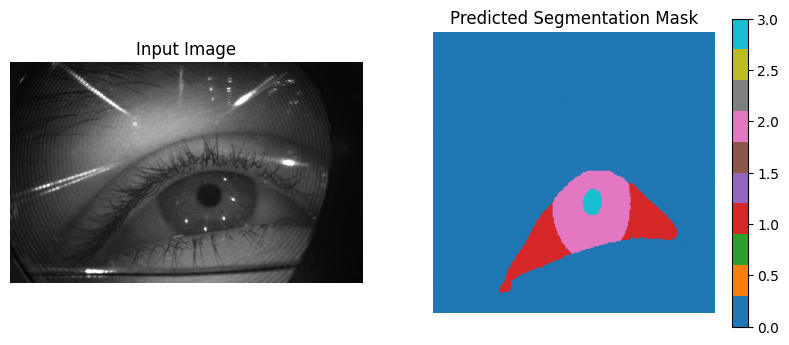

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

image_path = './openEDS/openEDS/S_10/10.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print("Original image shape:", image.shape)
img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(image, (224, 224))
img = np.expand_dims(img, axis=-1)
img = np.expand_dims(img, axis=0)
# img = img.astype(np.float32) / 255.0  # Normalize

# Predict
predicted_mask = model.predict(img)
predicted_mask = np.argmax(predicted_mask, axis=-1)[0]

# custom_objects = {
#             'GaussianBlur': GaussianBlur,
#             'GaussianNoiseLayer': GaussianNoiseLayer,
#             'WeightNoiseLayer': WeightNoiseLayer,
#             'FeatureEncryptionLayer': FeatureEncryptionLayer,
#             'LightInvarianceLayer': LightInvarianceLayer,
#             'dice_coefficient_multiclass': dice_coefficient_multiclass,
#             'iou_metric_multiclass': iou_metric_multiclass,
#         }
# model = tf.keras.models.load_model("privacy_preserving_unet_medium_light_invariance.h5", custom_objects=custom_objects)

print("Predicted mask shape:", predicted_mask.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='tab10', vmin=0, vmax=3)
plt.title("Predicted Segmentation Mask")
plt.colorbar()
plt.axis('off')